# Hospital Readmission Prediction using Machine Learning

## 1. Introduction

Hospital readmission is one of the most important quality indicators in healthcare systems worldwide. Patients who are readmitted shortly after discharge often experience poor health outcomes, increased treatment costs, and greater pressure on hospital resources. Predicting the likelihood of readmission enables healthcare providers to identify high-risk patients early and implement preventive interventions before discharge.

This module focuses on developing a machine learning-based hospital readmission prediction system using a real-world synthetic healthcare dataset containing patient demographics, hospital admissions, diagnoses, laboratory values, billing information, and hospital characteristics.

Unlike traditional single-table datasets, this dataset consists of multiple relational tables that must be integrated before analysis. Therefore, the first stage of this module involves data integration to create a comprehensive master dataset suitable for machine learning.

The final objective is to predict whether a patient will be readmitted within 30 days after discharge by utilizing demographic information, clinical measurements, previous medical history, hospital characteristics, and diagnosis information.

## 2. Objectives

The objectives of this module are:

- Load all healthcare datasets.
- Understand the structure of each dataset.
- Merge multiple relational tables into a single master dataset.
- Perform exploratory data analysis.
- Clean and preprocess the data.
- Engineer meaningful predictive features.
- Train multiple machine learning algorithms.
- Compare baseline and tuned models.
- Explain model predictions using SHAP.
- Develop a hospital readmission prediction system.

## 3. Dataset Description

The dataset consists of five interconnected healthcare tables.

### Patients
Contains demographic information such as age, gender, insurance type, previous admissions, and comorbidity count.

### Admissions
Contains hospitalization details including admission type, discharge information, laboratory values, procedures, and readmission labels.

### Diagnoses
Contains ICD-10 diagnosis codes assigned during each admission.

### Billing
Contains hospital expenditure and payment-related information.

### Hospitals
Contains hospital characteristics including location, hospital tier, number of beds, and teaching status.

The prediction target for this study is:

**readmitted_30d**

where:

- 0 = No Readmission
- 1 = Readmitted within 30 Days

In [33]:
# ==========================================================
# 4. IMPORT LIBRARIES
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [34]:
# ==========================================================
# 5. LOAD DATASETS
# ==========================================================
import pandas as pd

patients = pd.read_csv("India_Hospital_Dataset/patients.csv")
admissions = pd.read_csv("India_Hospital_Dataset/admissions.csv")
diagnoses = pd.read_csv("India_Hospital_Dataset/diagnoses.csv")
billing = pd.read_csv("India_Hospital_Dataset/billing.csv")
hospitals = pd.read_csv("India_Hospital_Dataset/hospitals.csv")

In [35]:
# ==========================================================
# 6. DATASET OVERVIEW
# ==========================================================

datasets = {
    "Patients": patients,
    "Admissions": admissions,
    "Diagnoses": diagnoses,
    "Billing": billing,
    "Hospitals": hospitals
}

for name, df in datasets.items():

    print("="*80)
    print(name.upper())
    print("="*80)

    print("Shape :", df.shape)

    display(df.head())

    print(df.info())

PATIENTS
Shape : (86400, 8)


,patient_id,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions
0,2b179f89-9af7-45cf-86b4-3e01a47a3b7b,36,F,Telangana,False,Private,0,0
1,ecaeb9f3-d263-4712-b9b6-3312af5626ca,56,F,Uttar Pradesh,False,ESI,0,0
2,0160a5b6-877e-41e6-b84a-a2a51b367a36,67,F,Telangana,False,ESI,3,0
3,216875fa-b49d-4c47-8c8d-7191ba34ac06,53,M,Haryana,False,Ayushman,3,0
4,a2f3181d-e3f2-4fd3-8057-05a492ffcfb2,60,M,Maharashtra,True,Ayushman,4,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   patient_id         86400 non-null  object
 1   age                86400 non-null  int64 
 2   gender             86400 non-null  object
 3   state              86400 non-null  object
 4   bpl_card           86400 non-null  bool  
 5   insurance_type     61685 non-null  object
 6   comorbidity_count  86400 non-null  int64 
 7   prev_admissions    86400 non-null  int64 
dtypes: bool(1), int64(3), object(4)
memory usage: 4.7+ MB
None
ADMISSIONS
Shape : (120000, 17)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   admission_id    120000 non-null  object 
 1   patient_id      120000 non-null  object 
 2   admit_date      120000 non-null  object 
 3   discharge_date  120000 non-null  object 
 4   los_days        120000 non-null  int64  
 5   admit_type      120000 non-null  object 
 6   ward_type       120000 non-null  object 
 7   hospital_id     120000 non-null  object 
 8   discharge_type  120000 non-null  object 
 9   num_procedures  120000 non-null  int64  
 10  charlson_index  120000 non-null  int64  
 11  hba1c           120000 non-null  float64
 12  creatinine      120000 non-null  float64
 13  haemoglobin     120000 non-null  float64
 14  systolic_bp     120000 non-null  int64  
 15  readmitted_30d  120000 non-null  int64  
 16  readmitted_7d   120000 non-null  int64  
dtypes: float64

,diag_id,admission_id,icd10_code,diag_desc,diag_rank,diag_category
0,3b448b98-6b78-4c7c-94c1-f832581c5052,bcb311d6-0808-498f-8ae1-11abe1fbc08e,E87,Metabolic / electrolyte disorder,1,Endocrine
1,137c0404-f1b6-4aca-95f5-2217812a6975,996ac6db-a192-46a0-b536-503a1c57994b,J45,Asthma,1,Respiratory
2,4bfb76a1-12ed-4cbd-b905-34d4bf3196f0,cc4849fa-b740-487b-beda-3086a18273c0,G40,Epilepsy,1,Neurological
3,754ec3d2-e940-4342-9e1d-d88a9acec626,cc4849fa-b740-487b-beda-3086a18273c0,A15,Pulmonary tuberculosis,2,Infectious
4,f4fa0d7b-0a68-4dd9-b7cf-db15c6bf3812,cc4849fa-b740-487b-beda-3086a18273c0,I48,Atrial fibrillation,3,Cardiovascular


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271341 entries, 0 to 271340
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   diag_id        271341 non-null  object
 1   admission_id   271341 non-null  object
 2   icd10_code     271341 non-null  object
 3   diag_desc      271341 non-null  object
 4   diag_rank      271341 non-null  int64 
 5   diag_category  271341 non-null  object
dtypes: int64(1), object(5)
memory usage: 12.4+ MB
None
BILLING
Shape : (120000, 6)


,bill_id,admission_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category
0,68e19242-4126-4a7a-afa2-9e6035cdcffa,bcb311d6-0808-498f-8ae1-11abe1fbc08e,18492,16630,1862,Lab
1,b740202e-1d7a-45b4-9575-21b35e219e37,996ac6db-a192-46a0-b536-503a1c57994b,1001,0,1001,Lab
2,f60fecaa-e769-42ea-bee8-58198bdd1208,cc4849fa-b740-487b-beda-3086a18273c0,59696,48650,11046,Room
3,32f41176-c088-4e9a-aa81-ae40f91b912a,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,72588,0,72588,Lab
4,cf80fba9-7fec-4b2e-b548-037a43dcf93c,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,9510,0,9510,Lab


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   bill_id            120000 non-null  object
 1   admission_id       120000 non-null  object
 2   total_cost_inr     120000 non-null  int64 
 3   govt_subsidy_inr   120000 non-null  int64 
 4   out_of_pocket_inr  120000 non-null  int64 
 5   cost_category      120000 non-null  object
dtypes: int64(3), object(3)
memory usage: 5.5+ MB
None
HOSPITALS
Shape : (33, 6)


,hospital_id,name,state,tier,beds,teaching
0,df0f948a-2202-459a-ba6f-7ffd7dedcc18,Government General Hospital Maharashtra,Maharashtra,tier2,314,True
1,3d59f4a6-ce9c-4945-8f1f-5929f09a7836,Government General Hospital Uttar Pradesh,Uttar Pradesh,tier2,481,True
2,aac12881-4dea-42f3-bf32-8add9d5eee49,Government General Hospital Tamil Nadu,Tamil Nadu,tier2,428,True
3,28879338-cd09-48bb-bedb-730b8ee8ab4e,Government General Hospital Karnataka,Karnataka,tier2,304,True
4,2f5c9dbb-cef7-46a2-8f35-ac5bdc0232c6,Government General Hospital West Bengal,West Bengal,tier2,632,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   hospital_id  33 non-null     object
 1   name         33 non-null     object
 2   state        33 non-null     object
 3   tier         33 non-null     object
 4   beds         33 non-null     int64 
 5   teaching     33 non-null     bool  
dtypes: bool(1), int64(1), object(4)
memory usage: 1.4+ KB
None


# 7. Data integration
## 7.1 Diagnosis Aggregation

Since one admission may contain multiple diagnosis records, the diagnosis table is first aggregated so that each admission corresponds to a single row. This prevents duplication during dataset merging and preserves essential diagnosis information for predictive modeling.

In [36]:
# ==========================================================
# 7.1 AGGREGATE DIAGNOSES
# ==========================================================

diagnosis_summary = (

    diagnoses

    .groupby("admission_id")

    .agg(

        diagnosis_count=("diag_id", "count"),

        primary_diagnosis=("diag_desc", "first"),

        primary_category=("diag_category", "first")

    )

    .reset_index()

)

print(diagnosis_summary.shape)

diagnosis_summary.head()

(120000, 4)


,admission_id,diagnosis_count,primary_diagnosis,primary_category
0,0001273a-4e21-47f3-8dff-877734fb010c,1,Malignant neoplasm — breast,Neoplasm
1,00020220-ca07-4b22-bed3-934e565d2875,1,Maternal care — uterine anomaly,Obstetric
2,0003b202-ff44-43ac-bc52-6075f4ecddf9,3,Type 1 diabetes mellitus,Endocrine
3,0004897e-6c81-44ed-bc91-b9ae47bedced,3,Epilepsy,Neurological
4,000616dc-80eb-4a95-a8cd-60245916a9a9,3,Respiratory distress — newborn,Perinatal


## 7.2 Merge Patient and Admission Information

Patient demographic information is merged with hospital admission records using the patient identifier.

In [37]:
master_df = admissions.merge(

    patients,

    on="patient_id",

    how="left"

)

print(master_df.shape)

(120000, 24)


## 7.3 Merge Billing Information

Hospital billing information is merged using the admission identifier.

In [38]:
master_df = master_df.merge(

    billing,

    on="admission_id",

    how="left"

)

print(master_df.shape)

(120000, 29)


## 7.4 Merge Hospital Information

Hospital characteristics are merged using the hospital identifier.

In [39]:
master_df = master_df.merge(

    hospitals,

    on="hospital_id",

    how="left",

    suffixes=("","_hospital")

)

print(master_df.shape)

(120000, 34)


## 7.5 Merge Diagnosis Information

The aggregated diagnosis summary is merged with the master dataset using the admission identifier.

In [40]:
master_df = master_df.merge(

    diagnosis_summary,

    on="admission_id",

    how="left"

)

print(master_df.shape)

(120000, 37)


## 7.6 Verify Master Dataset

The final master dataset is inspected to verify that all tables have been successfully integrated.

In [41]:
# ==========================================================
# FINAL MASTER DATASET
# ==========================================================

print("="*80)
print("MASTER DATASET")
print("="*80)

print("Shape :", master_df.shape)

display(master_df.head())

print(master_df.info())

MASTER DATASET
Shape : (120000, 37)


,admission_id,patient_id,admit_date,discharge_date,los_days,admit_type,ward_type,hospital_id,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,bill_id,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,name,state_hospital,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,bcb311d6-0808-498f-8ae1-11abe1fbc08e,6960d399-8398-4db4-9a90-0b329b81bc2b,2024-01-23,2024-01-27,4,Elective,General,b22e7b51-2ea6-4611-a8e5-d3d24ec779d8,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,68e19242-4126-4a7a-afa2-9e6035cdcffa,18492,16630,1862,Lab,Government General Hospital Odisha,Odisha,tier2,359,True,1,Metabolic / electrolyte disorder,Endocrine
1,996ac6db-a192-46a0-b536-503a1c57994b,ec1999d4-f097-4881-91a5-6f9b1f8dac78,2019-11-18,2019-11-19,1,OPD,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0,b740202e-1d7a-45b4-9575-21b35e219e37,1001,0,1001,Lab,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,1,Asthma,Respiratory
2,cc4849fa-b740-487b-beda-3086a18273c0,ed56abac-a0ba-44db-a816-b5da4183b9b5,2019-11-22,2019-11-27,5,Emergency,General,eae7c9ec-65c8-4d48-92f3-7da7b3e2b227,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,f60fecaa-e769-42ea-bee8-58198bdd1208,59696,48650,11046,Room,Apollo/Manipal (Private) Karnataka,Karnataka,tier1,1018,True,3,Epilepsy,Neurological
3,b38cdd03-165c-428c-b221-9f1d4cf8bdeb,90c335d5-dd71-46c8-acd2-656653f421c6,2020-03-05,2020-03-16,11,Emergency,ICU,df4431ea-1acf-4e77-963c-6173e9787151,Recovered,1,2,4.7,1.40,8.8,159,1,0,56,F,Kerala,False,NaN,0,1,32f41176-c088-4e9a-aa81-ae40f91b912a,72588,0,72588,Lab,District Hospital Uttar Pradesh,Uttar Pradesh,tier3,191,False,1,Heart failure,Cardiovascular
4,6a154ec0-92cc-43f5-ada5-ede0a600ce9e,694988e8-9ef5-43e8-aefe-c6b98b1e96fe,2018-05-30,2018-06-04,5,Emergency,General,8b1e01b7-9f0e-413f-b330-454d271a5c6e,Recovered,1,5,5.0,0.94,11.3,173,1,0,69,F,Kerala,False,NaN,2,0,cf80fba9-7fec-4b2e-b548-037a43dcf93c,9510,0,9510,Lab,District Hospital Madhya Pradesh,Madhya Pradesh,tier3,67,False,3,Malignant neoplasm — breast,Neoplasm


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 37 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   admission_id       120000 non-null  object 
 1   patient_id         120000 non-null  object 
 2   admit_date         120000 non-null  object 
 3   discharge_date     120000 non-null  object 
 4   los_days           120000 non-null  int64  
 5   admit_type         120000 non-null  object 
 6   ward_type          120000 non-null  object 
 7   hospital_id        120000 non-null  object 
 8   discharge_type     120000 non-null  object 
 9   num_procedures     120000 non-null  int64  
 10  charlson_index     120000 non-null  int64  
 11  hba1c              120000 non-null  float64
 12  creatinine         120000 non-null  float64
 13  haemoglobin        120000 non-null  float64
 14  systolic_bp        120000 non-null  int64  
 15  readmitted_30d     120000 non-null  int64  
 16  re

# 8. Exploratory Data Analysis (EDA)
## 8.1 Dataset Summary

After integrating all relational tables, the resulting master dataset contains patient demographics, hospital admission details, diagnosis information, laboratory measurements, billing information, and hospital characteristics.

The objective of this exploratory data analysis is to understand the overall structure of the dataset, identify potential data quality issues, analyze feature distributions, and explore relationships between variables before preprocessing and model development.

In [42]:
# ==========================================================
# 8.1 DATASET SUMMARY
# ==========================================================

print("="*80)
print("MASTER DATASET SUMMARY")
print("="*80)

print(f"Rows    : {master_df.shape[0]}")
print(f"Columns : {master_df.shape[1]}")

print("\nColumn Names\n")
print(master_df.columns.tolist())

print("\nData Types\n")
display(master_df.dtypes.to_frame("Data Type"))

MASTER DATASET SUMMARY
Rows    : 120000
Columns : 37

Column Names

['admission_id', 'patient_id', 'admit_date', 'discharge_date', 'los_days', 'admit_type', 'ward_type', 'hospital_id', 'discharge_type', 'num_procedures', 'charlson_index', 'hba1c', 'creatinine', 'haemoglobin', 'systolic_bp', 'readmitted_30d', 'readmitted_7d', 'age', 'gender', 'state', 'bpl_card', 'insurance_type', 'comorbidity_count', 'prev_admissions', 'bill_id', 'total_cost_inr', 'govt_subsidy_inr', 'out_of_pocket_inr', 'cost_category', 'name', 'state_hospital', 'tier', 'beds', 'teaching', 'diagnosis_count', 'primary_diagnosis', 'primary_category']

Data Types



,Data Type
admission_id,object
patient_id,object
admit_date,object
discharge_date,object
los_days,int64
admit_type,object
ward_type,object
hospital_id,object
discharge_type,object
num_procedures,int64


## 8.2 Missing Value Analysis

Missing value analysis is performed to identify incomplete observations that may influence model performance. Features with missing values will be handled during the preprocessing stage using appropriate imputation techniques.

MISSING VALUE ANALYSIS


,Missing Values,Percentage
insurance_type,33987,28.32
patient_id,0,0.00
admit_date,0,0.00
discharge_date,0,0.00
admission_id,0,0.00
los_days,0,0.00
admit_type,0,0.00
hospital_id,0,0.00
ward_type,0,0.00
num_procedures,0,0.00


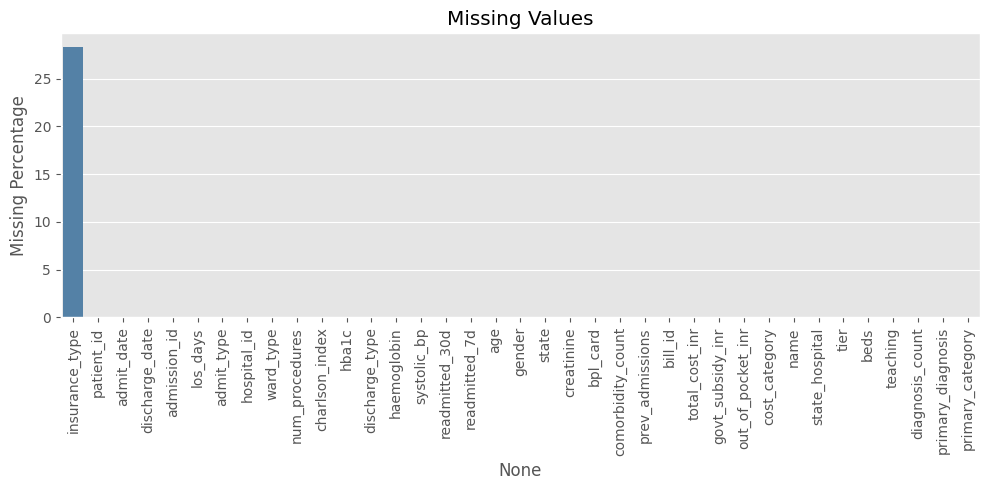

In [43]:
# ==========================================================
# 8.2 MISSING VALUES
# ==========================================================

missing = pd.DataFrame({
    "Missing Values": master_df.isnull().sum(),
    "Percentage": round(master_df.isnull().mean()*100,2)
})

missing = missing.sort_values(
    by="Missing Values",
    ascending=False
)

print("="*80)
print("MISSING VALUE ANALYSIS")
print("="*80)

display(missing)

plt.figure(figsize=(10,5))

sns.barplot(
    x=missing.index,
    y=missing["Percentage"],
    color="steelblue"
)

plt.xticks(rotation=90)

plt.ylabel("Missing Percentage")

plt.title("Missing Values")

plt.tight_layout()

plt.show()

## 8.3 Duplicate Record Analysis

Duplicate observations may introduce bias during model training. Therefore, duplicate records are identified to determine whether removal is required.

In [44]:
# ==========================================================
# 8.3 DUPLICATES
# ==========================================================

duplicates = master_df.duplicated().sum()

print("="*80)
print("DUPLICATE RECORD ANALYSIS")
print("="*80)

print("Duplicate Records :", duplicates)

print(
    "Duplicate Percentage :",
    round((duplicates/len(master_df))*100,2),
    "%"
)

DUPLICATE RECORD ANALYSIS
Duplicate Records : 0
Duplicate Percentage : 0.0 %


## 8.4 Readmission Distribution

The target variable represents whether a patient was readmitted within 30 days following discharge. Understanding the distribution of the target classes is essential for identifying class imbalance prior to model development.

READMISSION DISTRIBUTION


,Count,Percentage
readmitted_30d,,
0,105790,88.16
1,14210,11.84


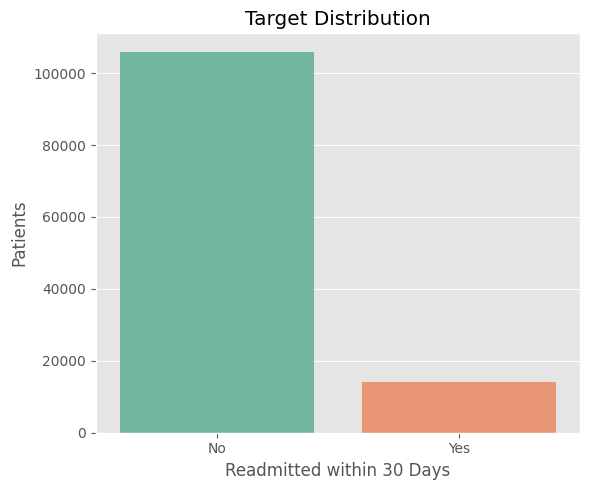

In [45]:
# ==========================================================
# 8.4 TARGET DISTRIBUTION
# ==========================================================

target = master_df["readmitted_30d"].value_counts()

target_df = pd.DataFrame({

    "Count":target,

    "Percentage":round(
        target/len(master_df)*100,
        2
    )

})

print("="*80)
print("READMISSION DISTRIBUTION")
print("="*80)

display(target_df)

plt.figure(figsize=(6,5))

sns.countplot(
    data=master_df,
    x="readmitted_30d",
    palette="Set2"
)

plt.xticks([0,1],["No","Yes"])

plt.xlabel("Readmitted within 30 Days")

plt.ylabel("Patients")

plt.title("Target Distribution")

plt.tight_layout()

plt.show()

## 8.5 Distribution of Categorical Variables

This section visualizes the distribution of important categorical variables in the dataset.

Since some variables contain a large number of unique categories, only the top 10 most frequent categories are displayed for better visualization.

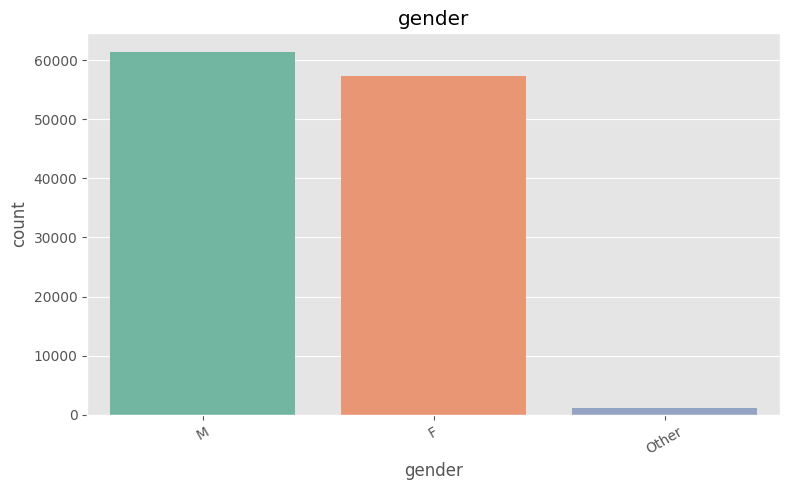

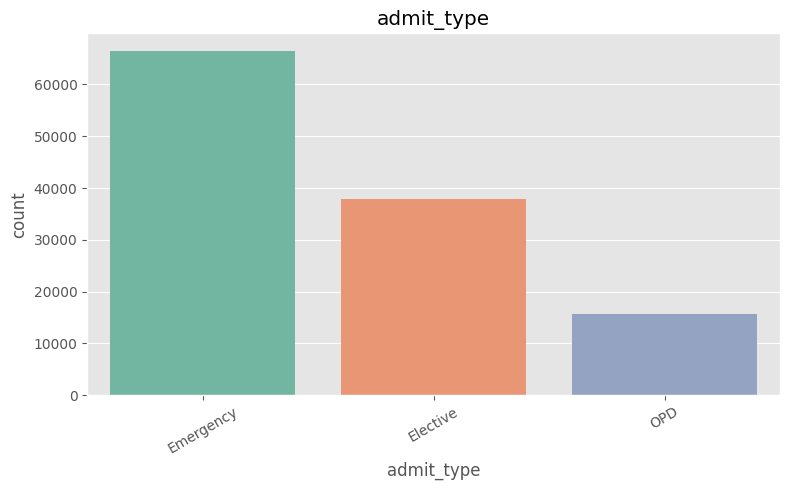

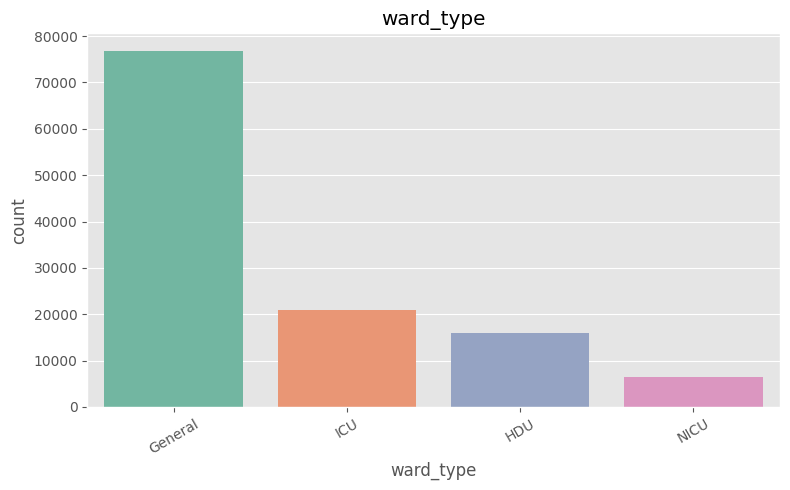

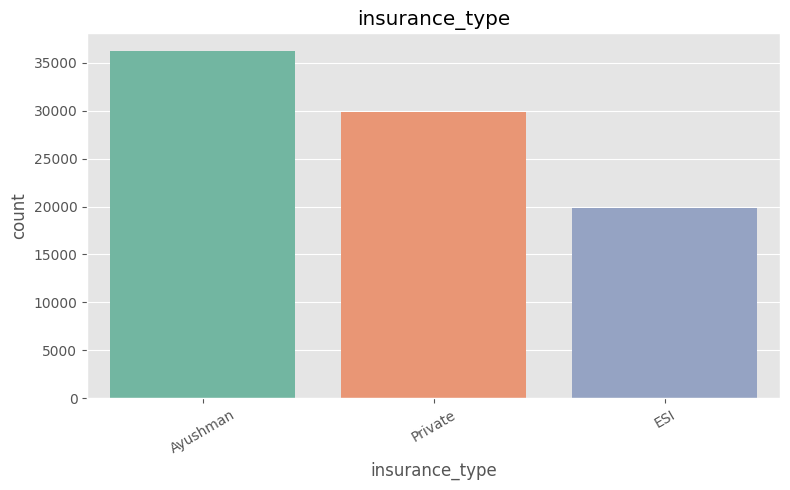

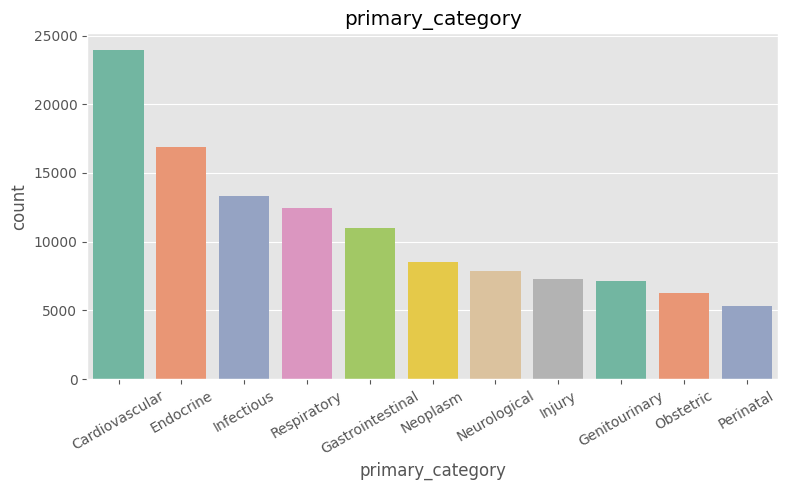

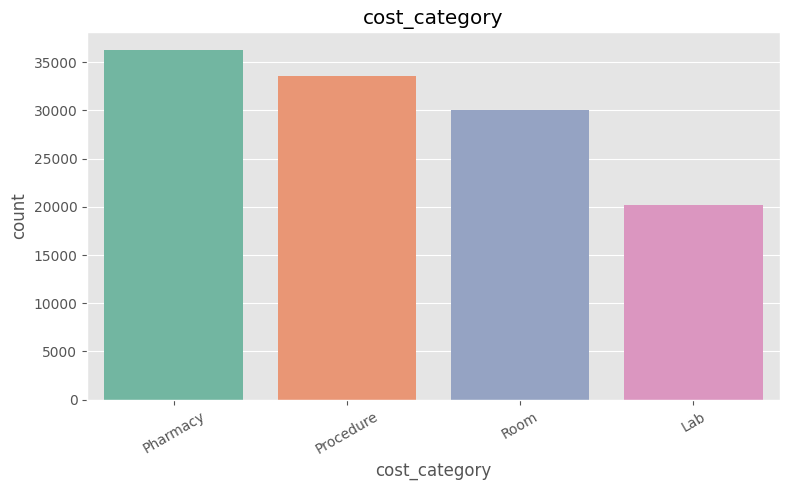

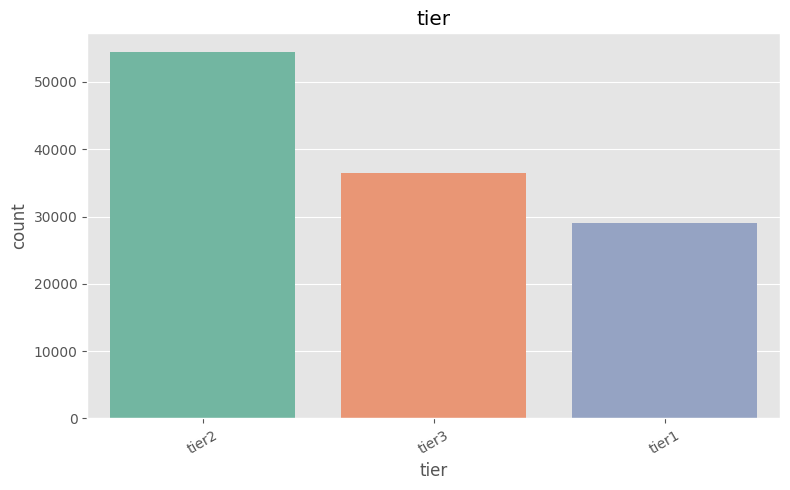

In [46]:
# ==========================================================
# 8.5 Distribution of Important Categorical Features
# ==========================================================

categorical_features = [
    "gender",
    "admit_type",
    "ward_type",
    "insurance_type",
    "primary_category",
    "cost_category",
    "tier"
]

for feature in categorical_features:

    plt.figure(figsize=(8,5))

    sns.countplot(
        data=master_df,
        x=feature,
        order=master_df[feature].value_counts().index,
        palette="Set2"
    )

    plt.title(feature)

    plt.xticks(rotation=30)

    plt.tight_layout()

    plt.show()

## 8.6 Top 10 Primary Diagnoses

The primary diagnosis variable contains numerous disease names. Therefore, only the ten most frequently occurring diagnoses are visualized to improve readability.

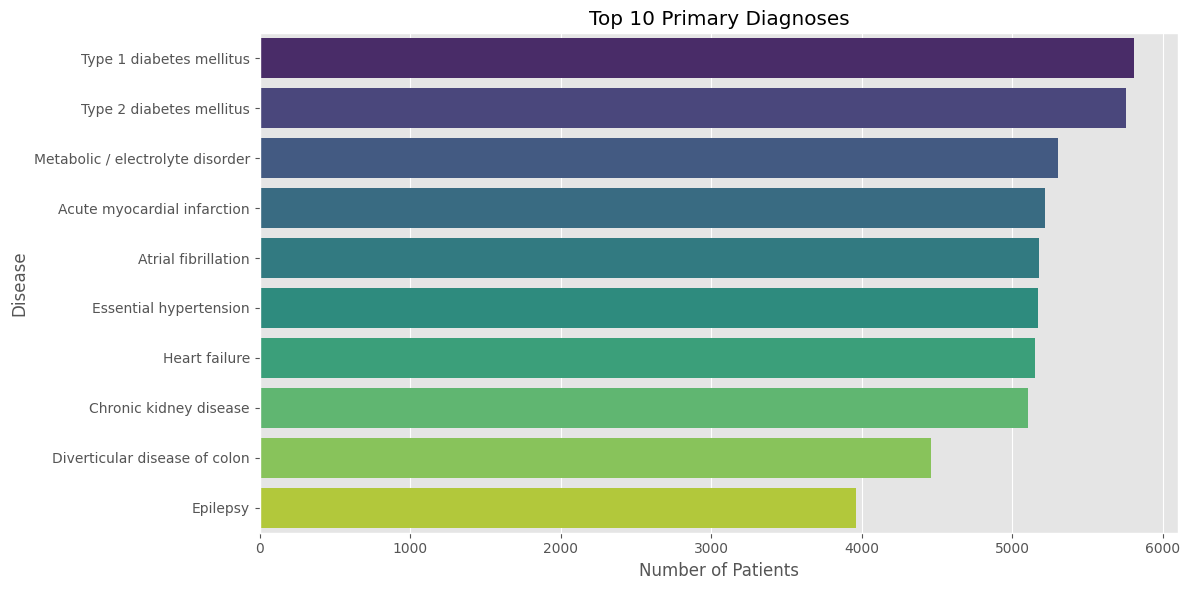

In [47]:
# ==========================================================
# Top 10 Diseases
# ==========================================================

top10 = master_df["primary_diagnosis"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    palette="viridis"
)

plt.title("Top 10 Primary Diagnoses")

plt.xlabel("Number of Patients")

plt.ylabel("Disease")

plt.tight_layout()

plt.show()

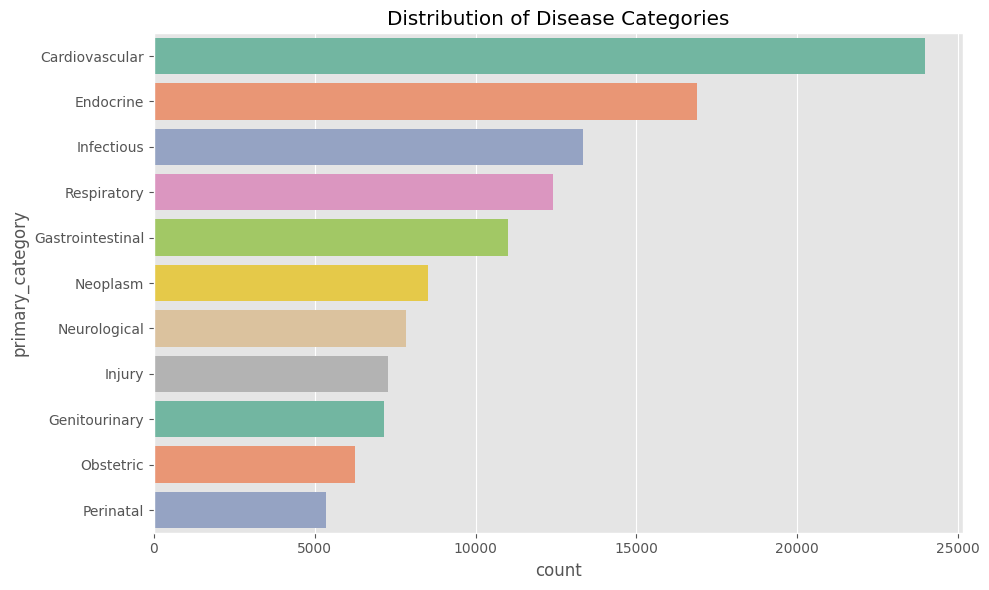

In [48]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=master_df,
    y="primary_category",
    order=master_df["primary_category"].value_counts().index,
    palette="Set2"
)

plt.title("Distribution of Disease Categories")

plt.tight_layout()

plt.show()

## 8.7 Relationship Between Categorical Features and 30-Day Readmission

This section examines the relationship between important categorical variables and the 30-day hospital readmission status.

Stacked bar charts are used to compare the proportion of patients who were readmitted and not readmitted across different categories.

<Figure size 900x500 with 0 Axes>

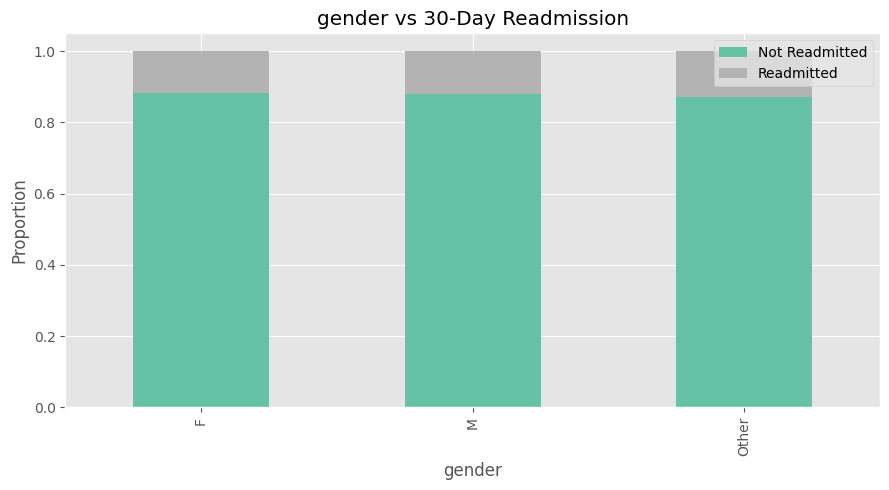

<Figure size 900x500 with 0 Axes>

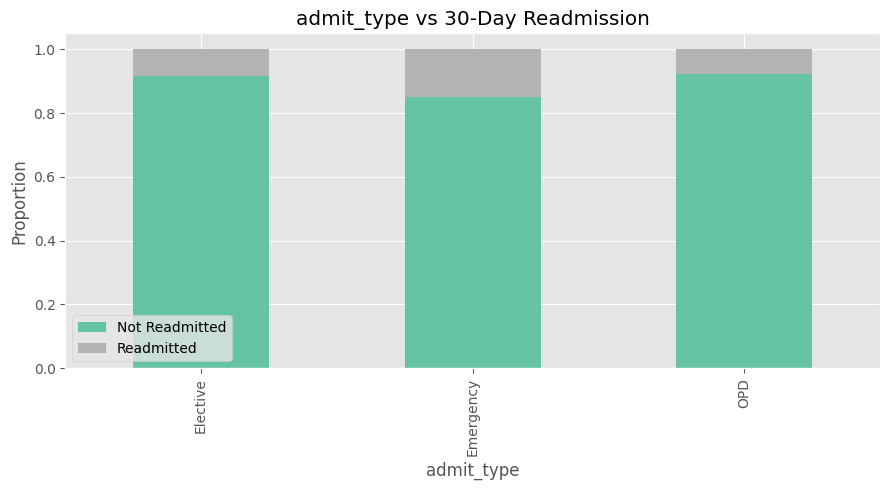

<Figure size 900x500 with 0 Axes>

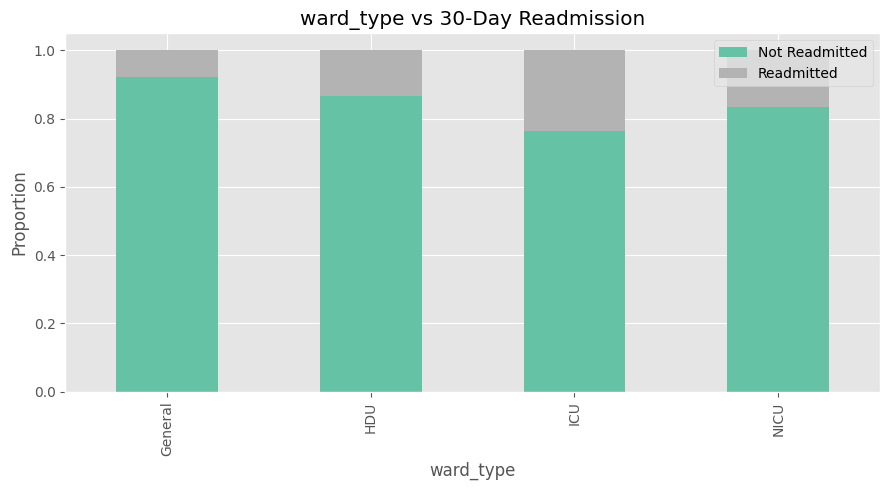

<Figure size 900x500 with 0 Axes>

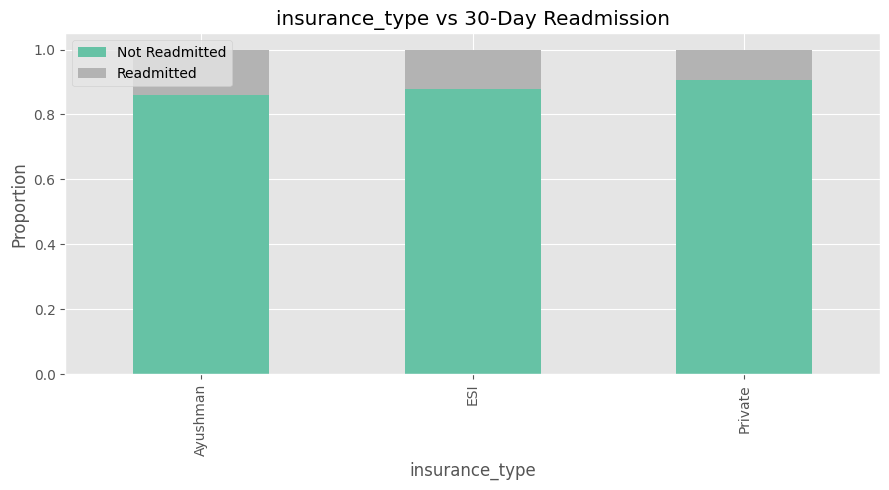

<Figure size 900x500 with 0 Axes>

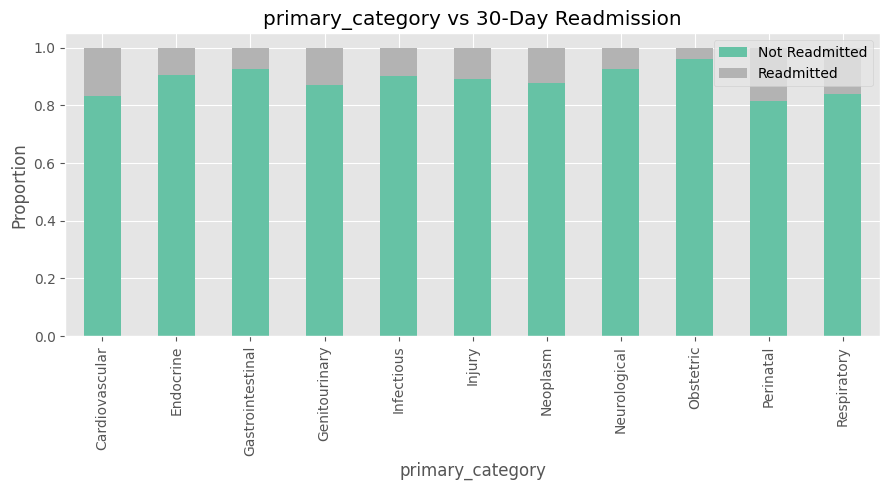

In [49]:
# ==========================================================
# 8.7 Categorical Features vs Readmission
# ==========================================================

categorical_features = [
    "gender",
    "admit_type",
    "ward_type",
    "insurance_type",
    "primary_category"
]

for feature in categorical_features:

    plt.figure(figsize=(9,5))

    pd.crosstab(
        master_df[feature],
        master_df["readmitted_30d"],
        normalize="index"
    ).plot(
        kind="bar",
        stacked=True,
        figsize=(9,5),
        colormap="Set2"
    )

    plt.title(f"{feature} vs 30-Day Readmission")
    plt.xlabel(feature)
    plt.ylabel("Proportion")

    plt.legend(["Not Readmitted","Readmitted"])

    plt.tight_layout()
    plt.show()

## 8.8 Distribution of Continuous Variables by Readmission Status

This section compares the distribution of important numerical variables between patients who were readmitted within 30 days and those who were not.

Boxplots help identify differences in central tendency, spread, and potential outliers.

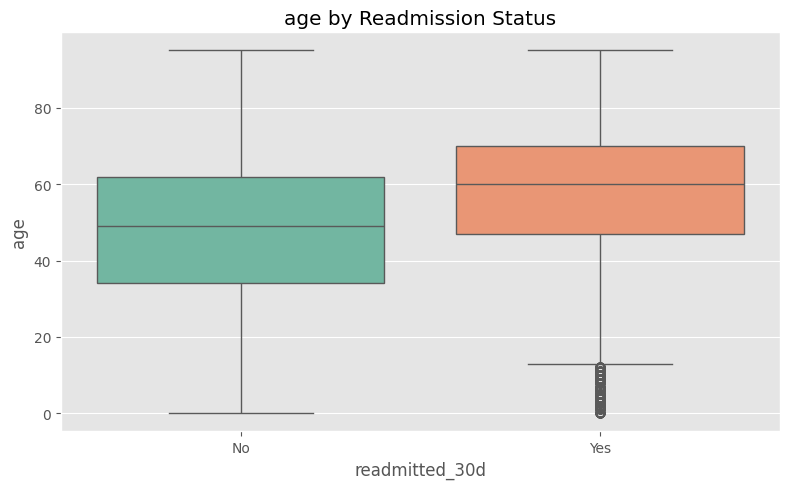

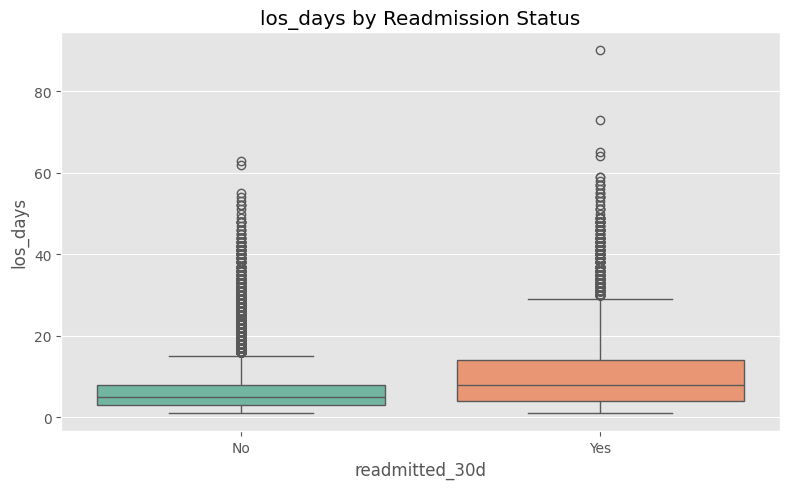

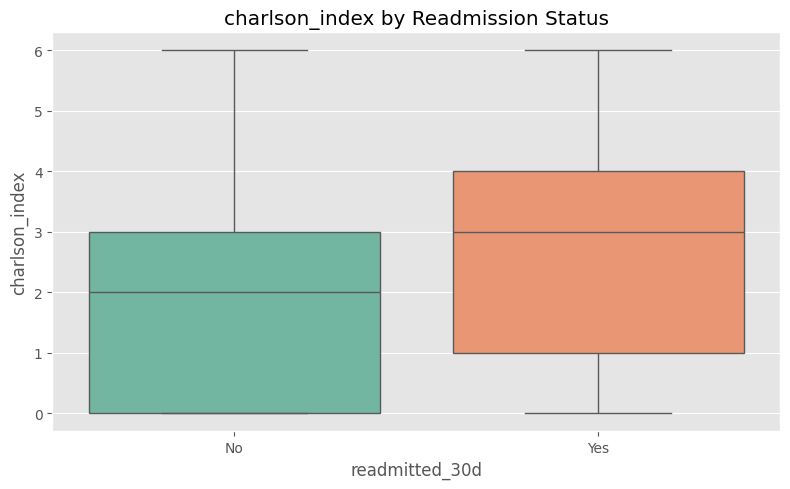

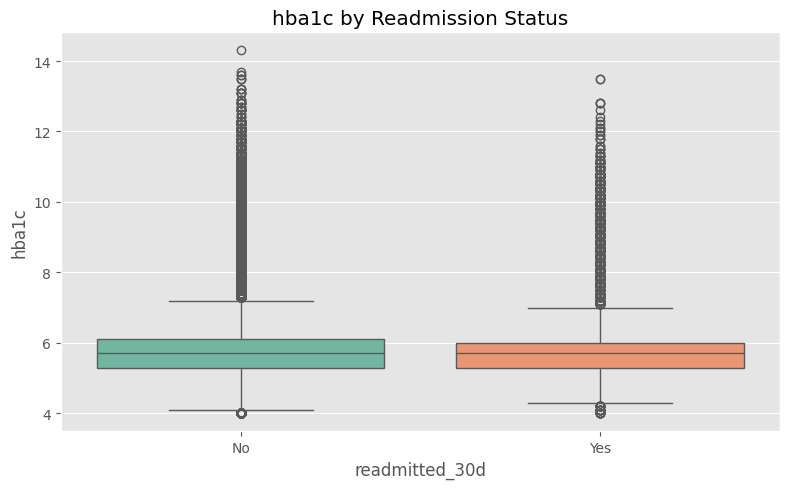

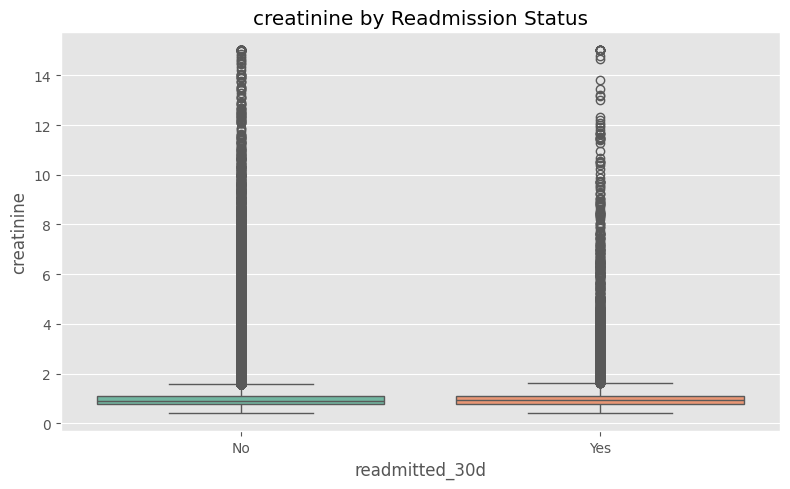

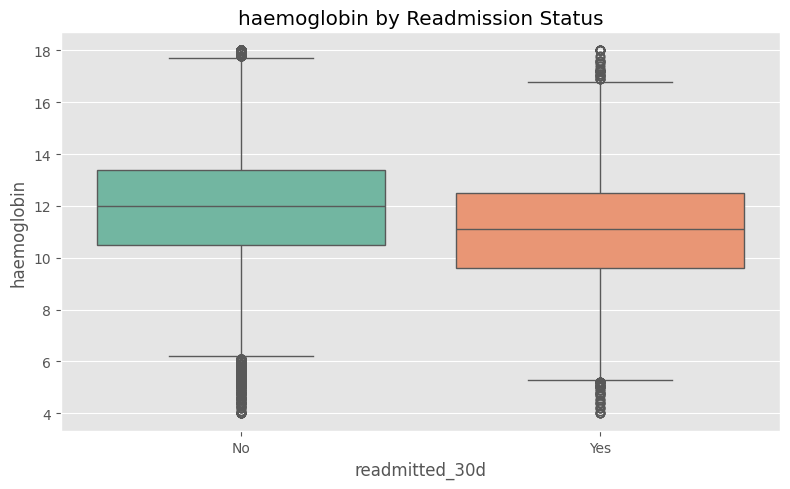

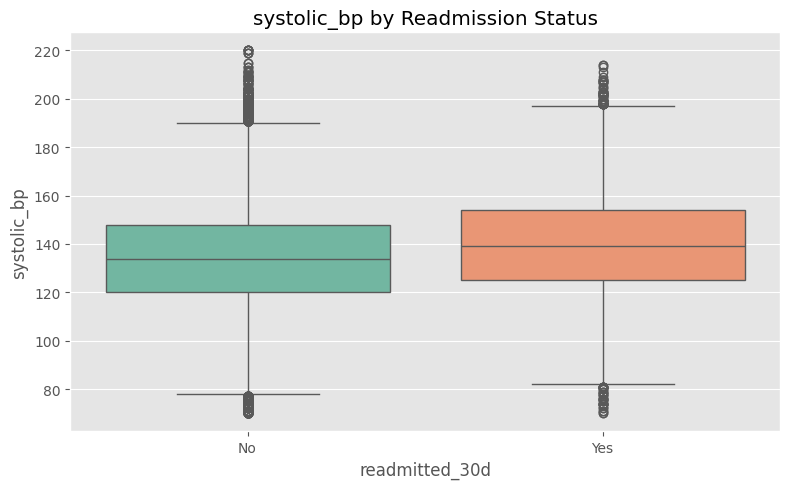

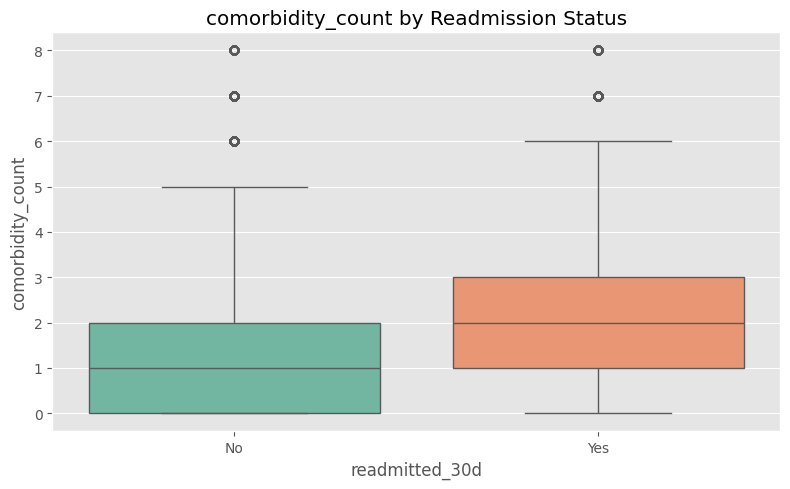

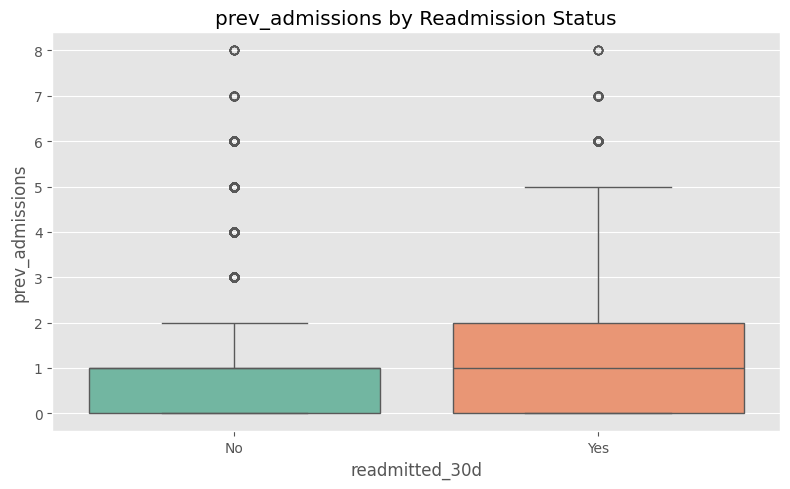

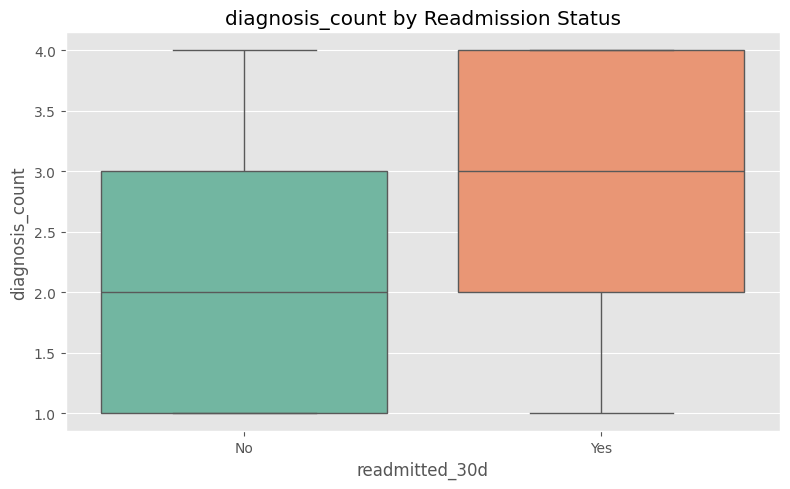

In [50]:
# ==========================================================
# 8.8 Continuous Features vs Readmission
# ==========================================================

continuous_features = [
    "age",
    "los_days",
    "charlson_index",
    "hba1c",
    "creatinine",
    "haemoglobin",
    "systolic_bp",
    "comorbidity_count",
    "prev_admissions",
    "diagnosis_count"
]

for feature in continuous_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=master_df,
        x="readmitted_30d",
        y=feature,
        palette="Set2"
    )

    plt.title(f"{feature} by Readmission Status")

    plt.xticks([0,1],["No","Yes"])

    plt.tight_layout()

    plt.show()

## 8.9 Correlation Analysis

Pearson correlation analysis is performed on numerical variables to identify relationships among clinical measurements and hospital-related factors.

The correlation heatmap helps detect multicollinearity and understand associations between variables.

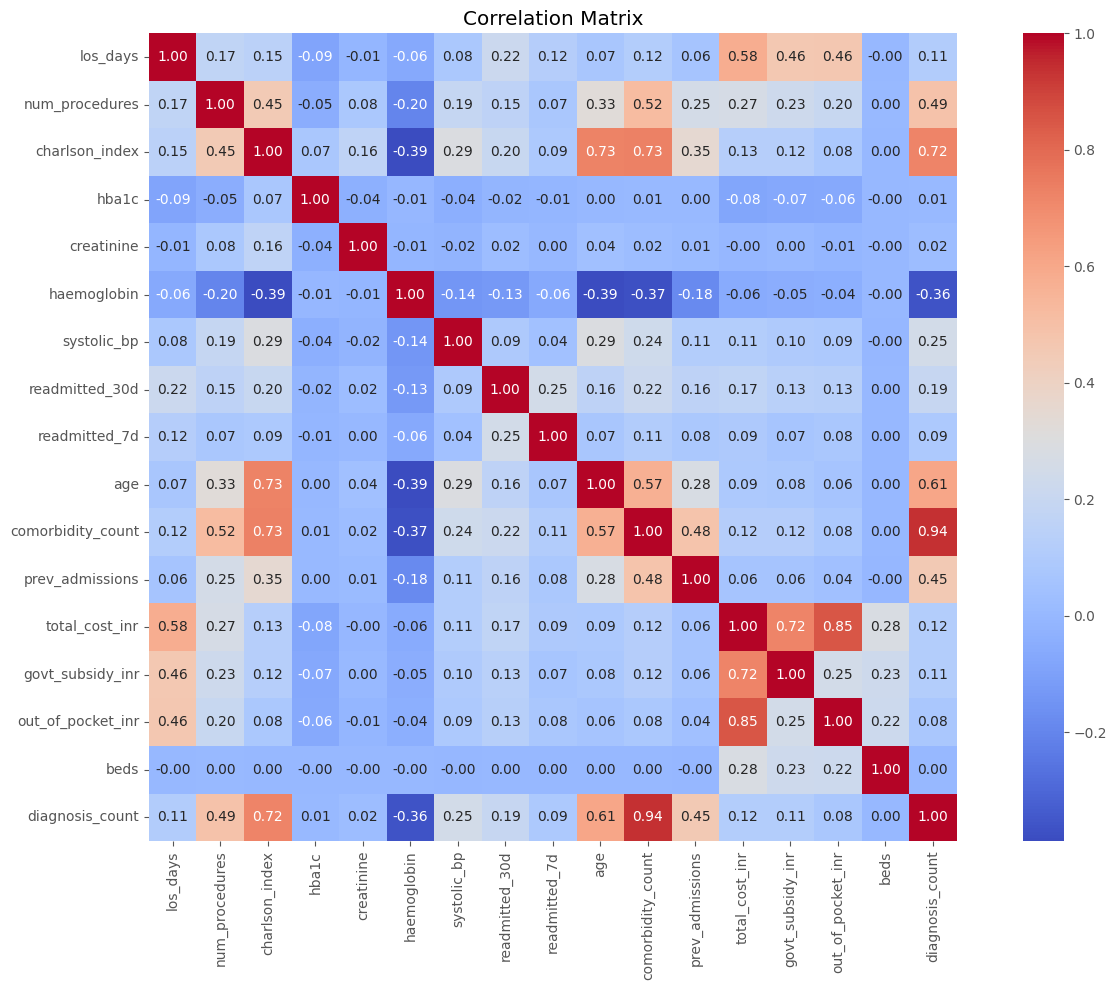

Correlation Matrix


,los_days,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,beds,diagnosis_count
los_days,1.000000,0.167297,0.145957,-0.085518,-0.012357,-0.063159,0.080877,0.218204,0.119882,0.069282,0.115214,0.059319,0.582470,0.462648,0.463838,-0.001621,0.108465
num_procedures,0.167297,1.000000,0.447379,-0.047991,0.083928,-0.197794,0.187226,0.154993,0.073911,0.325192,0.519477,0.252191,0.268368,0.229544,0.201237,0.004676,0.489129
charlson_index,0.145957,0.447379,1.000000,0.074738,0.160879,-0.387260,0.293626,0.199160,0.086483,0.728092,0.730800,0.354877,0.125683,0.123798,0.081838,0.000987,0.719122
hba1c,-0.085518,-0.047991,0.074738,1.000000,-0.040040,-0.005454,-0.044924,-0.015158,-0.010071,0.001088,0.006544,0.003140,-0.082671,-0.068279,-0.063843,-0.001877,0.006333
creatinine,-0.012357,0.083928,0.160879,-0.040040,1.000000,-0.010326,-0.018887,0.021083,0.002468,0.037435,0.019719,0.010461,-0.004310,0.003503,-0.008705,-0.001896,0.021562
haemoglobin,-0.063159,-0.197794,-0.387260,-0.005454,-0.010326,1.000000,-0.139604,-0.131524,-0.063473,-0.385072,-0.371489,-0.182750,-0.058753,-0.050079,-0.044189,-0.002508,-0.360392
systolic_bp,0.080877,0.187226,0.293626,-0.044924,-0.018887,-0.139604,1.000000,0.090246,0.043299,0.290683,0.235881,0.111607,0.114658,0.096129,0.087456,-0.004835,0.250730
readmitted_30d,0.218204,0.154993,0.199160,-0.015158,0.021083,-0.131524,0.090246,1.000000,0.250878,0.156359,0.217649,0.158402,0.167046,0.134149,0.131907,0.002330,0.192953
readmitted_7d,0.119882,0.073911,0.086483,-0.010071,0.002468,-0.063473,0.043299,0.250878,1.000000,0.068673,0.108300,0.082584,0.092260,0.066794,0.078408,0.001467,0.086955
age,0.069282,0.325192,0.728092,0.001088,0.037435,-0.385072,0.290683,0.156359,0.068673,1.000000,0.569032,0.277830,0.087141,0.078954,0.061979,0.001608,0.606546


In [51]:
# ==========================================================
# 8.9 Correlation Matrix
# ==========================================================

numerical_columns = master_df.select_dtypes(include=["int64","float64"]).columns

corr = master_df[numerical_columns].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

print("="*80)
print("Correlation Matrix")
print("="*80)

corr

## 8.10 Key Insights from Exploratory Data Analysis

Major findings obtained from exploratory data analysis include:

- The dataset contains 120,000 hospital admissions collected from hospitals across India.
- Only the `insurance_type` feature contains missing values (approximately 28%), while all remaining variables are complete.
- No duplicate records were identified.
- The dataset is imbalanced, with approximately 88% non-readmitted patients and 12% readmitted patients.
- Clinical variables such as Charlson Index, HbA1c, Creatinine, Length of Stay, and Previous Admissions show noticeable variation between readmitted and non-readmitted patients.
- Cardiovascular, Respiratory, Endocrine, and Neurological diseases constitute a substantial proportion of admissions.
- The correlation analysis indicates low to moderate correlations among numerical variables, suggesting minimal multicollinearity.
- These findings justify the use of class-balancing techniques and machine learning models for predicting 30-day hospital readmission.

# 9. Data Preprocessing

## 9.1 Introduction

Data preprocessing is a crucial stage in machine learning that transforms raw healthcare data into a clean and structured format suitable for predictive modeling.

The preprocessing pipeline includes handling missing values, removing unnecessary variables, encoding categorical features, splitting the dataset into training and testing subsets, balancing the target classes using SMOTE, and scaling numerical variables where required.

These preprocessing steps improve model performance, reduce bias caused by class imbalance, and ensure that machine learning algorithms learn meaningful patterns from the clinical data.

## 9.2 Removing Unnecessary Features

Several identifier and administrative variables do not contribute to prediction and may introduce data leakage. These columns are removed before model training.

In [52]:
# ==========================================================
# 9.2 Remove Unnecessary Columns
# ==========================================================

master_df = master_df.copy()

columns_to_drop = [
    "admission_id",
    "patient_id",
    "hospital_id",
    "bill_id",
    "name",
    "admit_date",
    "discharge_date",
    "state_hospital"
]

master_df.drop(columns=columns_to_drop, inplace=True)

print("="*80)
print("Dataset Shape After Removing Unnecessary Columns")
print("="*80)

print(master_df.shape)
master_df.head()

Dataset Shape After Removing Unnecessary Columns
(120000, 29)


,los_days,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,4,Elective,General,Recovered,0,0,6.3,0.86,16.2,157,0,0,46,M,Haryana,False,ESI,0,0,18492,16630,1862,Lab,tier2,359,True,1,Metabolic / electrolyte disorder,Endocrine
1,1,OPD,General,Recovered,1,0,5.2,1.23,13.1,156,0,0,31,M,Andhra Pradesh,False,NaN,0,0,1001,0,1001,Lab,tier3,67,False,1,Asthma,Respiratory
2,5,Emergency,General,Recovered,0,2,5.6,0.67,10.9,130,1,0,53,F,West Bengal,False,Private,2,3,59696,48650,11046,Room,tier1,1018,True,3,Epilepsy,Neurological
3,11,Emergency,ICU,Recovered,1,2,4.7,1.40,8.8,159,1,0,56,F,Kerala,False,NaN,0,1,72588,0,72588,Lab,tier3,191,False,1,Heart failure,Cardiovascular
4,5,Emergency,General,Recovered,1,5,5.0,0.94,11.3,173,1,0,69,F,Kerala,False,NaN,2,0,9510,0,9510,Lab,tier3,67,False,3,Malignant neoplasm — breast,Neoplasm


## 9.3 Handling Missing Values

The dataset contains missing values only in the insurance type attribute. Instead of removing these records, missing values are replaced with the category "Unknown" to preserve all patient admissions.

In [53]:
# ==========================================================
# 9.3 Missing Value Treatment
# ==========================================================

master_df["insurance_type"] = master_df["insurance_type"].fillna("Unknown")

print("="*80)
print("Remaining Missing Values")
print("="*80)

print(master_df.isnull().sum().sort_values(ascending=False).head())

Remaining Missing Values
los_days          0
admit_type        0
ward_type         0
discharge_type    0
num_procedures    0
dtype: int64


## 9.4 Feature and Target Separation

The target variable for this study is 30-day hospital readmission. All remaining variables are considered predictor features.

In [54]:
# ==========================================================
# 9.4 Feature Target Separation
# ==========================================================

X = master_df.drop(
    columns=[
        "readmitted_30d",
        "readmitted_7d"
    ]
)

y = master_df["readmitted_30d"]

print("="*80)
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

print("\nTarget Distribution")
print(y.value_counts())

Feature Matrix Shape : (120000, 27)
Target Vector Shape  : (120000,)

Target Distribution
readmitted_30d
0    105790
1     14210
Name: count, dtype: int64


## 9.5 Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Therefore, categorical variables are transformed into numerical representations using Label Encoding.

Binary variables are converted into 0 and 1, while multi-class categorical variables are encoded into integer labels.

In [55]:
# ==========================================================
# 9.5 Label Encoding
# ==========================================================

from sklearn.preprocessing import LabelEncoder

master_df_encoded = master_df.copy()

label_encoders = {}

categorical_columns = master_df_encoded.select_dtypes(include="object").columns

for col in categorical_columns:

    le = LabelEncoder()

    master_df_encoded[col] = le.fit_transform(master_df_encoded[col].astype(str))

    label_encoders[col] = le

print("="*80)
print("Categorical Features Encoded Successfully")
print("="*80)

master_df_encoded.head()

Categorical Features Encoded Successfully


,los_days,admit_type,ward_type,discharge_type,num_procedures,charlson_index,hba1c,creatinine,haemoglobin,systolic_bp,readmitted_30d,readmitted_7d,age,gender,state,bpl_card,insurance_type,comorbidity_count,prev_admissions,total_cost_inr,govt_subsidy_inr,out_of_pocket_inr,cost_category,tier,beds,teaching,diagnosis_count,primary_diagnosis,primary_category
0,4,0,0,2,0,0,6.3,0.86,16.2,157,0,0,46,1,3,False,1,0,0,18492,16630,1862,0,1,359,True,1,21,1
1,1,2,0,2,1,0,5.2,1.23,13.1,156,0,0,31,1,0,False,3,0,0,1001,0,1001,0,2,67,False,1,2,10
2,5,1,0,2,0,2,5.6,0.67,10.9,130,1,0,53,0,14,False,2,2,3,59696,48650,11046,3,0,1018,True,3,11,7
3,11,1,2,2,1,2,4.7,1.40,8.8,159,1,0,56,0,5,False,3,0,1,72588,0,72588,0,2,191,False,1,15,0
4,5,1,0,2,1,5,5.0,0.94,11.3,173,1,0,69,0,5,False,3,2,0,9510,0,9510,0,2,67,False,3,17,6


## 9.6 Feature and Target Separation

After encoding, the dataset is separated into predictor variables (X) and the target variable (y). The prediction target is 30-day hospital readmission.

In [56]:
# ==========================================================
# 9.6 Feature Target Separation
# ==========================================================

X = master_df_encoded.drop(
    columns=[
        "readmitted_30d",
        "readmitted_7d"
    ]
)

y = master_df_encoded["readmitted_30d"]

print("="*80)
print("Feature Matrix :", X.shape)
print("Target Vector  :", y.shape)

Feature Matrix : (120000, 27)
Target Vector  : (120000,)


## 9.7 Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio.

Stratified sampling is applied to preserve the original class distribution in both datasets.

In [57]:
# ==========================================================
# 9.7 Train Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("="*80)
print("TRAIN TEST SPLIT")
print("="*80)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

print("\nTraining Class Distribution")

display(
    y_train.value_counts().to_frame("Count").assign(
        Percentage=lambda x: round(x["Count"]/len(y_train)*100,2)
    )
)

TRAIN TEST SPLIT
Training Features : (96000, 27)
Testing Features  : (24000, 27)
Training Labels   : (96000,)
Testing Labels    : (24000,)

Training Class Distribution


,Count,Percentage
readmitted_30d,,
0,84632,88.16
1,11368,11.84


## 9.8 Handling Class Imbalance Using SMOTE

The training dataset exhibits significant class imbalance. Synthetic Minority Oversampling Technique (SMOTE) is applied only to the training data to generate synthetic minority samples while preventing information leakage from the testing dataset.

In [58]:
# ==========================================================
# 9.8 SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("="*80)
print("SMOTE COMPLETED")
print("="*80)

print("Training Shape Before :", X_train.shape)
print("Training Shape After  :", X_train_smote.shape)

display(
    y_train_smote.value_counts().to_frame("Count").assign(
        Percentage=lambda x: round(x["Count"]/len(y_train_smote)*100,2)
    )
)

SMOTE COMPLETED
Training Shape Before : (96000, 27)
Training Shape After  : (169264, 27)


,Count,Percentage
readmitted_30d,,
0,84632,50.0
1,84632,50.0


## 9.9 Feature Scaling

Numerical features are standardized using StandardScaler. Although tree-based algorithms are insensitive to feature scaling, scaled datasets are prepared for algorithms such as Logistic Regression and Support Vector Machine.

In [59]:
# ==========================================================
# 9.9 Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("="*80)
print("FEATURE SCALING COMPLETED")
print("="*80)

print("Scaled Training :", X_train_scaled.shape)

print("Scaled Testing  :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Scaled Training : (169264, 27)
Scaled Testing  : (24000, 27)


# 11. Baseline Machine Learning Models

After preprocessing, the dataset is used to train multiple machine learning algorithms for predicting hospital readmission within 30 days.

Several supervised learning algorithms are evaluated to compare their predictive performance. The models are assessed using multiple evaluation metrics including Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, Confusion Matrix, and Classification Report.

The objective is to identify the best-performing model for predicting patient readmission.

In [60]:
# ==========================================================
# SECTION 11.2
# Import Machine Learning Libraries
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import time

In [61]:
# ==========================================================
# Store Results
# ==========================================================

results = []

In [62]:
# ==========================================================
# Logistic Regression
# ==========================================================

start = time.time()

lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train_smote)

pred = lr.predict(X_test_scaled)
prob = lr.predict_proba(X_test_scaled)[:,1]

end = time.time()

acc = accuracy_score(y_test,pred)
pre = precision_score(y_test,pred)
rec = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
auc = roc_auc_score(y_test,prob)

results.append([
    "Logistic Regression",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])

print("="*70)
print("Logistic Regression")
print("="*70)

print(classification_report(y_test,pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.75      0.82     21158
           1       0.20      0.47      0.28      2842

    accuracy                           0.72     24000
   macro avg       0.56      0.61      0.55     24000
weighted avg       0.83      0.72      0.76     24000



In [63]:
# ==========================================================
# Decision Tree
# ==========================================================

start=time.time()

dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote,y_train_smote)

pred=dt.predict(X_test)

prob=dt.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "Decision Tree",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("Decision tree")
print("="*70)
print(classification_report(y_test,pred))

Decision tree
              precision    recall  f1-score   support

           0       0.90      0.80      0.85     21158
           1       0.18      0.33      0.23      2842

    accuracy                           0.75     24000
   macro avg       0.54      0.56      0.54     24000
weighted avg       0.81      0.75      0.78     24000



In [64]:
# ==========================================================
# Random Forest
# ==========================================================

start=time.time()

rf=RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_smote,y_train_smote)

pred=rf.predict(X_test)

prob=rf.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "Random Forest",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("Random Forest")
print("="*70)
print(classification_report(y_test,pred))

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     21158
           1       0.28      0.23      0.25      2842

    accuracy                           0.84     24000
   macro avg       0.59      0.57      0.58     24000
weighted avg       0.83      0.84      0.83     24000



In [65]:
# ==========================================================
# XGBoost
# ==========================================================

start=time.time()

xgb=XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_estimators=200,
    learning_rate=0.05
)

xgb.fit(X_train_smote,y_train_smote)

pred=xgb.predict(X_test)

prob=xgb.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "XGBoost",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("XGBoost")
print("="*70)
print(classification_report(y_test,pred))

XGBoost
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     21158
           1       0.32      0.21      0.25      2842

    accuracy                           0.85     24000
   macro avg       0.61      0.58      0.59     24000
weighted avg       0.83      0.85      0.84     24000



In [66]:
# ==========================================================
# LightGBM
# ==========================================================

start=time.time()

lgb=LGBMClassifier(
    random_state=42,
    n_estimators=200,
    learning_rate=0.05
)

lgb.fit(X_train_smote,y_train_smote)

pred=lgb.predict(X_test)

prob=lgb.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "LightGBM",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])

print(classification_report(y_test,pred))

[LightGBM] [Info] Number of positive: 84632, number of negative: 84632
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2225
[LightGBM] [Info] Number of data points in the train set: 169264, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     21158
           1       0.49      0.14      0.21      2842

    accuracy                           0.88     24000
   macro avg       0.69      0.56      0.57     24000
weighted avg       0.85      0.88      0.85     24000



In [67]:
# ==========================================================
# CatBoost
# ==========================================================

start=time.time()

cat=CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=0
)

cat.fit(X_train_smote,y_train_smote)

pred=cat.predict(X_test)

prob=cat.predict_proba(X_test)[:,1]

end=time.time()

acc=accuracy_score(y_test,pred)
pre=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
auc=roc_auc_score(y_test,prob)

results.append([
    "CatBoost",
    acc,
    pre,
    rec,
    f1,
    auc,
    end-start
])
print("="*70)
print("CatBoost")
print("="*70)

print(classification_report(y_test,pred))

CatBoost
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     21158
           1       0.47      0.12      0.20      2842

    accuracy                           0.88     24000
   macro avg       0.68      0.55      0.57     24000
weighted avg       0.84      0.88      0.85     24000



In [68]:
# ==========================================================
# Model Comparison
# ==========================================================

results_df=pd.DataFrame(results)

results_df.columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Training Time (s)"
]

results_df=results_df.sort_values(
    by="ROC AUC",
    ascending=False
)

print("="*80)
print("BASELINE MODEL COMPARISON")
print("="*80)

display(results_df)

BASELINE MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
4,LightGBM,0.880875,0.489199,0.135468,0.212180,0.750614,4.924022
5,CatBoost,0.879917,0.473333,0.124912,0.197661,0.737782,14.739223
2,Random Forest,0.839875,0.281917,0.227657,0.251898,0.714178,72.094532
3,XGBoost,0.853000,0.317941,0.210767,0.253491,0.710756,4.100658
0,Logistic Regression,0.717917,0.203234,0.473258,0.284355,0.655702,0.597263
1,Decision Tree,0.746750,0.182247,0.326531,0.233930,0.564863,6.237397


# 12. Hyperparameter Tuning

Hyperparameter tuning is performed to improve the predictive performance of the best baseline models.

Instead of tuning every algorithm, only the top-performing models identified during baseline evaluation are optimized. This reduces computational cost while improving model generalization.

The following models are tuned:

- LightGBM
- CatBoost
- Random Forest

The optimized models are then compared using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Training Time.

In [69]:
# ==========================================================
# SECTION 12.2
# Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV

In [70]:
# ==========================================================
# Random Forest Hyperparameter Tuning
# ==========================================================

rf_params = {
    "n_estimators":[200,300],
    "max_depth":[15,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42,n_jobs=-1),
    param_distributions=rf_params,
    n_iter=5,
    cv=3,
    scoring="roc_auc",
    random_state=42,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train_smote,y_train_smote)

best_rf = rf_search.best_estimator_

print("="*70)
print("Best Random Forest Parameters")
print("="*70)

print(rf_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Random Forest Parameters
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}


In [71]:
# ==========================================================
# LightGBM Hyperparameter Tuning
# ==========================================================

lgb_params = {

    "learning_rate":[0.03,0.05,0.1],
    "num_leaves":[31,50,70],
    "max_depth":[6,8,10],
    "n_estimators":[200,300]
}

lgb_search = RandomizedSearchCV(

    estimator=LGBMClassifier(random_state=42),

    param_distributions=lgb_params,

    n_iter=5,

    cv=3,

    scoring="roc_auc",

    random_state=42,

    verbose=1,

    n_jobs=-1
)

lgb_search.fit(X_train_smote,y_train_smote)

best_lgb = lgb_search.best_estimator_

print("="*70)
print("Best LightGBM Parameters")
print("="*70)

print(lgb_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[LightGBM] [Info] Number of positive: 84632, number of negative: 84632
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037989 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2225
[LightGBM] [Info] Number of data points in the train set: 169264, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best LightGBM Parameters
{'num_leaves': 70, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1}


In [72]:
# ==========================================================
# CatBoost Hyperparameter Tuning
# ==========================================================

cat_params = {

    "depth":[4,6,8],

    "learning_rate":[0.03,0.05,0.1],

    "iterations":[200,300,400]
}

cat_search = RandomizedSearchCV(

    estimator=CatBoostClassifier(
        verbose=0,
        random_state=42
    ),

    param_distributions=cat_params,

    n_iter=5,

    cv=3,

    scoring="roc_auc",

    random_state=42,

    verbose=1,

    n_jobs=-1
)

cat_search.fit(X_train_smote,y_train_smote)

best_cat = cat_search.best_estimator_

print("="*70)
print("Best CatBoost Parameters")
print("="*70)

print(cat_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best CatBoost Parameters
{'learning_rate': 0.05, 'iterations': 300, 'depth': 6}


In [73]:
# ==========================================================
# Evaluate Tuned Models
# ==========================================================

tuned_results=[]

models={

    "Random Forest":best_rf,

    "LightGBM":best_lgb,

    "CatBoost":best_cat

}

for name,model in models.items():

    start=time.time()

    pred=model.predict(X_test)

    prob=model.predict_proba(X_test)[:,1]

    end=time.time()

    tuned_results.append([

        name,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred),

        roc_auc_score(y_test,prob),

        end-start

    ])

tuned_df=pd.DataFrame(

    tuned_results,

    columns=[

        "Model",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC",

        "Prediction Time (s)"

    ]

)

tuned_df=tuned_df.sort_values(

    by="ROC AUC",

    ascending=False

)

print("="*80)
print("TUNED MODEL COMPARISON")
print("="*80)

display(tuned_df)

TUNED MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Prediction Time (s)
1,LightGBM,0.881000,0.489943,0.119986,0.192764,0.744453,0.552286
2,CatBoost,0.879917,0.473333,0.124912,0.197661,0.737782,0.064515
0,Random Forest,0.814625,0.257177,0.299437,0.276703,0.706949,2.357926


In [74]:
# ==========================================================
# Best Tuned Model
# ==========================================================

best_model_name=tuned_df.iloc[0]["Model"]

print("="*70)
print("BEST TUNED MODEL")
print("="*70)

print(best_model_name)

BEST TUNED MODEL
LightGBM


# 13. Final Model Evaluation

The optimized LightGBM model is selected as the final prediction model based on its superior overall performance.

To comprehensively evaluate the model, several performance metrics and visualization techniques are used, including:

- Confusion Matrix
- ROC Curve
- Precision–Recall Curve
- Feature Importance
- SHAP Explainability

These evaluations provide insights into the predictive capability and interpretability of the final model.

In [75]:
# ==========================================================
# SECTION 13.2
# Final Model Prediction
# ==========================================================

final_model = best_lgb

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:,1]

print("="*70)
print("FINAL MODEL")
print("="*70)

print(classification_report(y_test,y_pred))

FINAL MODEL
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     21158
           1       0.49      0.12      0.19      2842

    accuracy                           0.88     24000
   macro avg       0.69      0.55      0.56     24000
weighted avg       0.84      0.88      0.85     24000



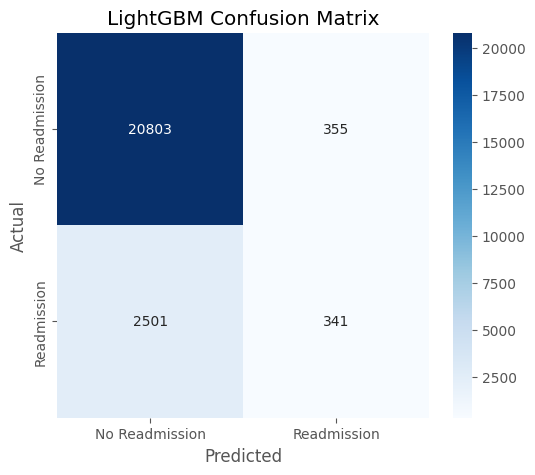

In [76]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission","Readmission"],
    yticklabels=["No Readmission","Readmission"]
)

plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

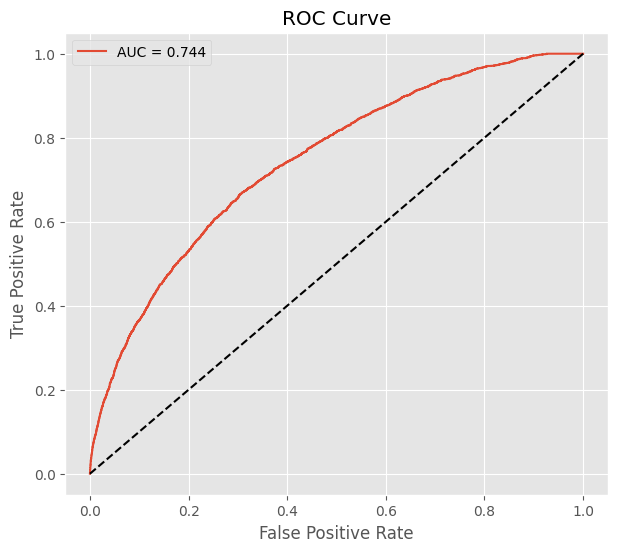

In [77]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr,tpr,_ = roc_curve(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr,tpr,label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

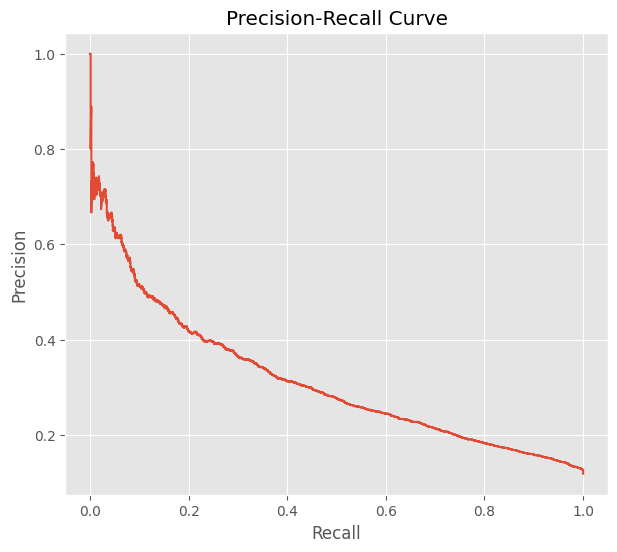

In [78]:
# ==========================================================
# Precision Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision,recall,_=precision_recall_curve(y_test,y_prob)

plt.figure(figsize=(7,6))

plt.plot(recall,precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

,Feature,Importance
6,hba1c,1584
22,beds,1467
25,primary_diagnosis,968
8,haemoglobin,845
7,creatinine,821
17,total_cost_inr,808
10,age,769
26,primary_category,706
9,systolic_bp,673
0,los_days,577


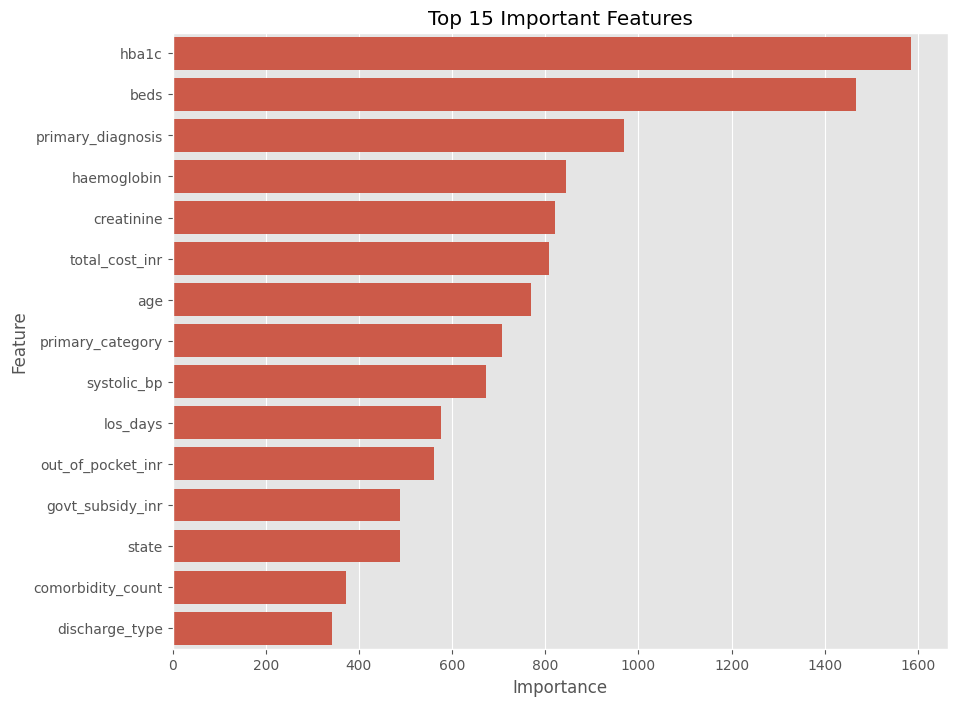

In [79]:
# ==========================================================
# Feature Importance
# ==========================================================

importance=pd.DataFrame({

    "Feature":X.columns,

    "Importance":final_model.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature"

)

plt.title("Top 15 Important Features")

plt.show()

# 14. Threshold Optimization

By default, LightGBM classifies patients using a probability threshold of 0.50.

However, hospital readmission prediction is an imbalanced classification problem. Lowering the decision threshold can improve the model's ability to identify high-risk patients (increase recall), although this may reduce precision.

This section evaluates different probability thresholds to determine the optimal balance between precision and recall.

In [80]:
# ==========================================================
# SECTION 14.2
# Threshold Optimization
# ==========================================================

import numpy as np

thresholds = np.arange(0.10,0.91,0.05)

threshold_results=[]

for t in thresholds:

    pred=(y_prob>=t).astype(int)

    threshold_results.append([

        t,

        accuracy_score(y_test,pred),

        precision_score(y_test,pred),

        recall_score(y_test,pred),

        f1_score(y_test,pred)

    ])

threshold_df=pd.DataFrame(

    threshold_results,

    columns=[

        "Threshold",

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ]

)

display(threshold_df)

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.577583,0.188578,0.777270,0.303517
1,0.15,0.705042,0.231734,0.643913,0.340814
2,0.20,0.776083,0.268471,0.516538,0.353309
3,0.25,0.819875,0.308210,0.418719,0.355065
4,0.30,0.847250,0.349525,0.336735,0.343011
5,0.35,0.863458,0.388974,0.268121,0.317434
6,0.40,0.871208,0.412509,0.206545,0.275264
7,0.45,0.878417,0.461145,0.158691,0.236126
8,0.50,0.881000,0.489943,0.119986,0.192764
9,0.55,0.882583,0.523904,0.092540,0.157297


In [81]:
# ==========================================================
# Select Best Threshold
# ==========================================================

best_threshold = threshold_df.loc[
    threshold_df["F1 Score"].idxmax(),
    "Threshold"
]

print("="*70)
print("BEST THRESHOLD")
print("="*70)

print(best_threshold)

BEST THRESHOLD
0.25000000000000006


In [82]:
# ==========================================================
# Final Prediction
# ==========================================================

final_prediction=(y_prob>=best_threshold).astype(int)

print(classification_report(y_test,final_prediction))

              precision    recall  f1-score   support

           0       0.92      0.87      0.90     21158
           1       0.31      0.42      0.36      2842

    accuracy                           0.82     24000
   macro avg       0.61      0.65      0.63     24000
weighted avg       0.85      0.82      0.83     24000



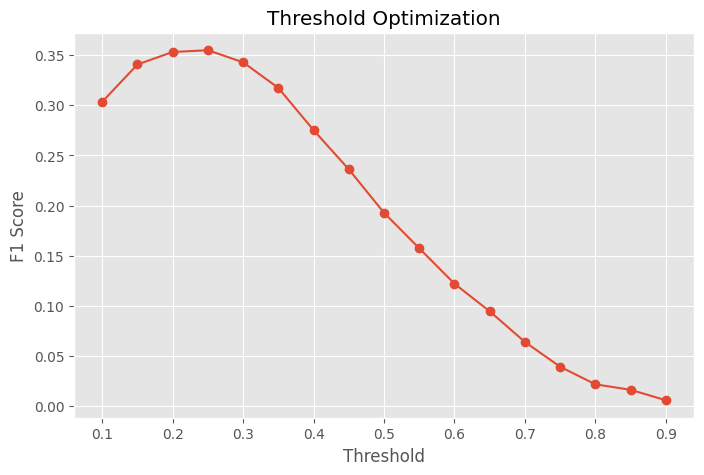

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.show()

Although the default threshold (0.50) achieved an overall accuracy of 88.1%, it produced a very low recall (12%) for the readmission class. To improve identification of high-risk patients, probability threshold optimization was performed. A threshold of 0.25 produced the highest F1-score while increasing recall to 42%, making the model substantially more useful for early clinical intervention.

# 14. Model Evaluation
## 14.1 Confusion Matrix

In [84]:
# ==========================================================
# 14.1 FINAL MODEL PREDICTIONS
# ==========================================================

# Best threshold obtained earlier
best_threshold = 0.25

# Probability predictions
y_prob = best_lgb.predict_proba(X_test)[:,1]

# Final predictions
y_pred_best = (y_prob >= best_threshold).astype(int)

print("Predictions Created Successfully")
print(y_pred_best[:10])

Predictions Created Successfully
[0 1 0 0 0 0 0 0 0 1]


In [85]:
# ==========================================================
# 14.2 CLASSIFICATION REPORT
# ==========================================================

from sklearn.metrics import classification_report

print("="*70)
print("FINAL MODEL")
print("="*70)

print(classification_report(y_test, y_pred_best))

FINAL MODEL
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     21158
           1       0.31      0.42      0.36      2842

    accuracy                           0.82     24000
   macro avg       0.61      0.65      0.63     24000
weighted avg       0.85      0.82      0.83     24000



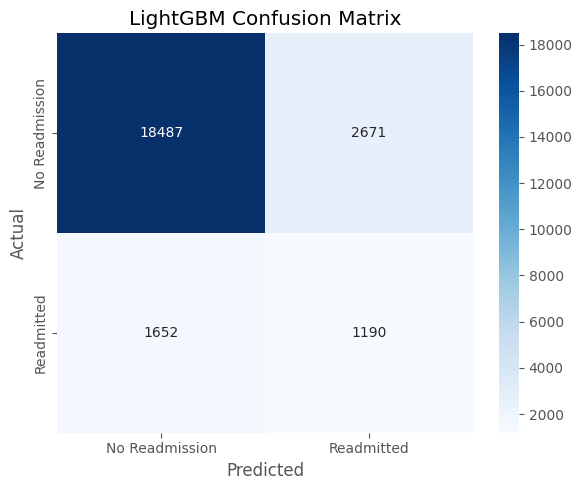

In [86]:
# ==========================================================
# 14.3 CONFUSION MATRIX
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Readmission","Readmitted"],
    yticklabels=["No Readmission","Readmitted"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LightGBM Confusion Matrix")

plt.tight_layout()
plt.show()

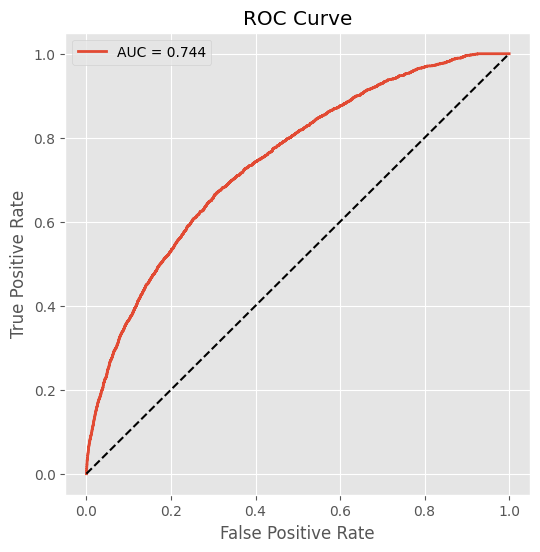

ROC AUC : 0.7445


In [87]:
# ==========================================================
# 14.4 ROC CURVE
# ==========================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

print("ROC AUC :", round(roc_auc,4))

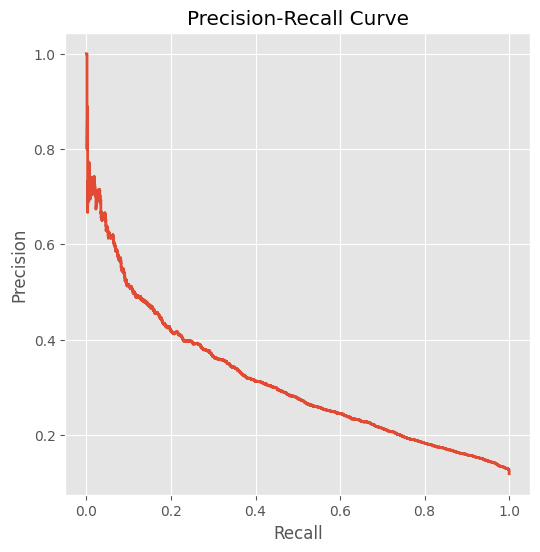

In [88]:
# ==========================================================
# 14.5 PRECISION RECALL CURVE
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,6))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

,Feature,Importance
6,hba1c,1584
22,beds,1467
25,primary_diagnosis,968
8,haemoglobin,845
7,creatinine,821
17,total_cost_inr,808
10,age,769
26,primary_category,706
9,systolic_bp,673
0,los_days,577


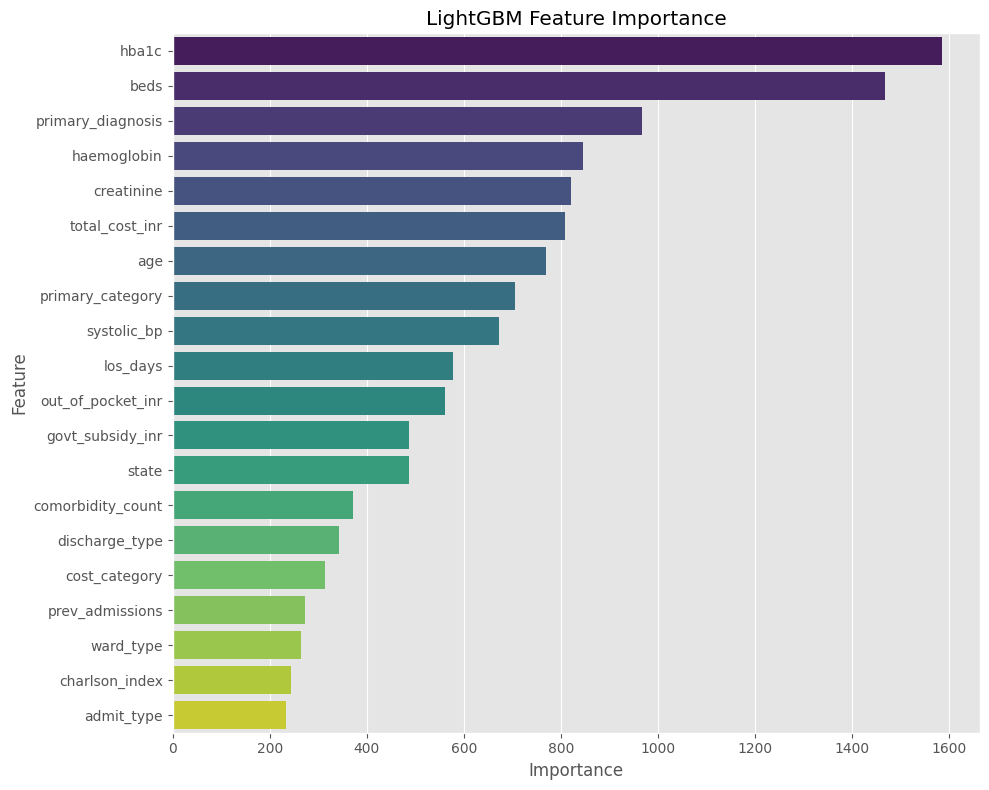

In [89]:
# ==========================================================
# 14.6 FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_lgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(20))

plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature",
    palette="viridis"
)

plt.title("LightGBM Feature Importance")

plt.tight_layout()

plt.show()

# 15. Model Explainability Using SHAP

## Objective

Machine learning models such as LightGBM often achieve high predictive performance but are difficult to interpret. In healthcare, model transparency is essential because clinicians need to understand which patient characteristics contribute most to the prediction of hospital readmission.

SHAP (SHapley Additive exPlanations) is an explainable Artificial Intelligence (XAI) technique based on cooperative game theory. It assigns each feature a contribution value, indicating how much that feature increases or decreases the prediction for a particular patient.

In this section, SHAP is used to:

- Explain the global behavior of the LightGBM model.
- Identify the most influential variables affecting hospital readmission.
- Interpret individual patient predictions.
- Improve the transparency and trustworthiness of the predictive model.

These explanations help healthcare professionals understand the reasoning behind the model's predictions and support informed clinical decision-making.

In [90]:
# ==========================================================
# 15.1 IMPORT SHAP
# ==========================================================

import shap

print("="*70)
print("SHAP Version")
print("="*70)

print(shap.__version__)

SHAP Version
0.49.1


In [91]:
# ==========================================================
# 15.2 CREATE SHAP EXPLAINER
# ==========================================================

explainer = shap.TreeExplainer(best_lgb)

shap_values = explainer.shap_values(X_test)

print("="*70)
print("SHAP VALUES GENERATED")
print("="*70)

SHAP VALUES GENERATED


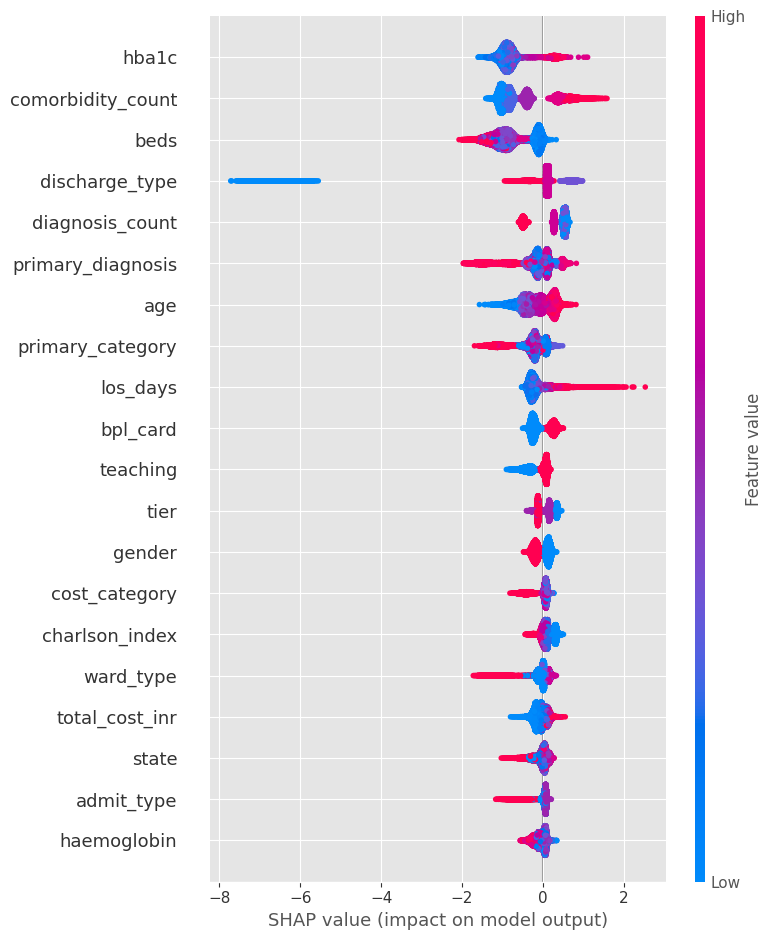

In [92]:
# ==========================================================
# 15.3 SHAP SUMMARY PLOT
# ==========================================================

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

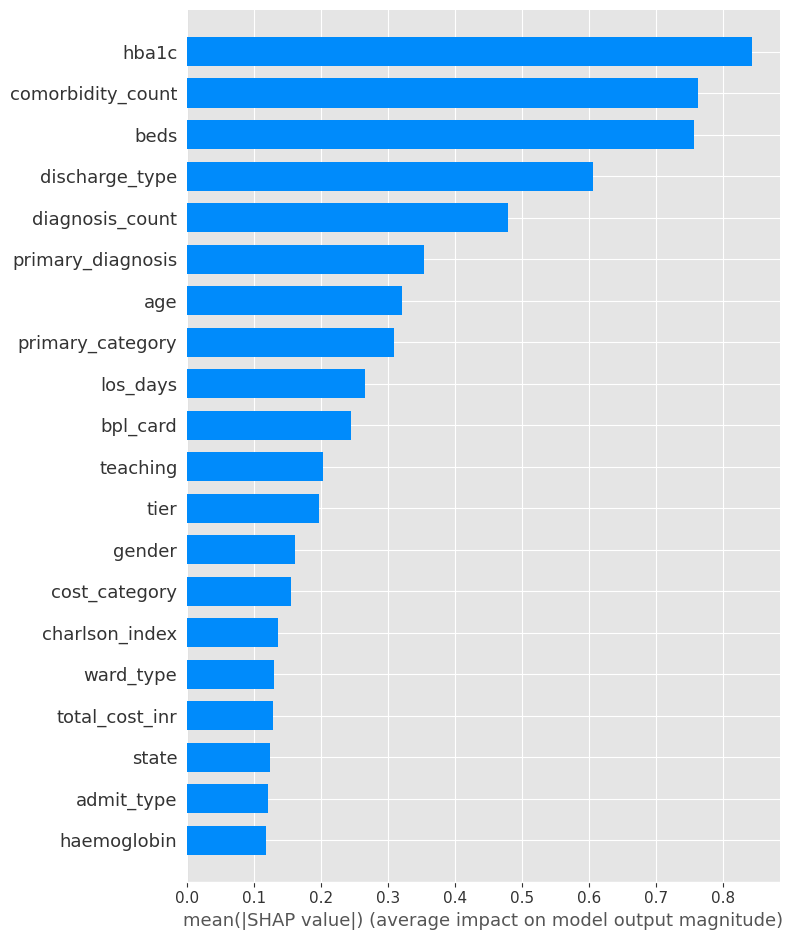

In [93]:
# ==========================================================
# 15.4 SHAP BAR PLOT
# ==========================================================

plt.figure(figsize=(10,7))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

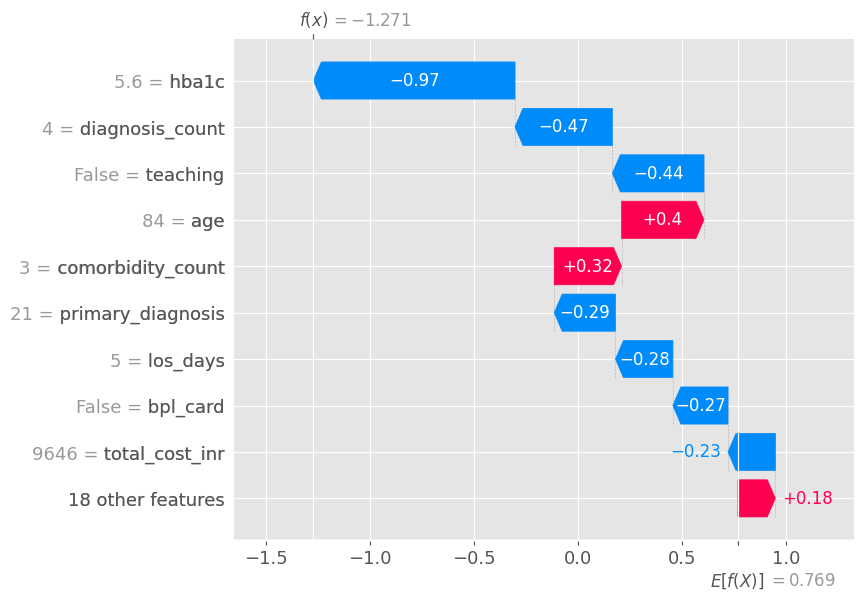

In [94]:
# ==========================================================
# 15.5 WATERFALL PLOT
# ==========================================================

patient = 0

shap.plots.waterfall(
    explainer(X_test.iloc[[patient]])[0]
)

In [95]:
# ==========================================================
# 15.6 FORCE PLOT
# ==========================================================

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

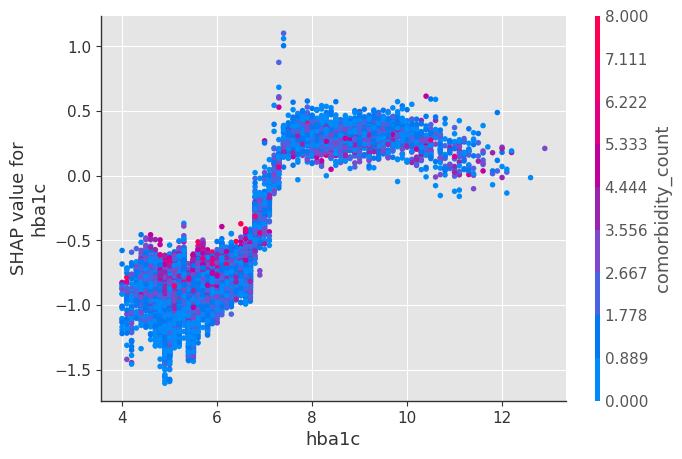

In [96]:
# ==========================================================
# 15.7 DEPENDENCE PLOT
# ==========================================================

shap.dependence_plot(
    "hba1c",
    shap_values,
    X_test
)

## Interpretation of SHAP Results

The SHAP analysis demonstrates that clinical variables play a significant role in predicting hospital readmission.

The most influential features include HbA1c, haemoglobin, creatinine, age, length of hospital stay, primary diagnosis, and comorbidity count. Higher HbA1c levels, impaired kidney function (creatinine), anemia (haemoglobin), advanced age, and prolonged hospitalization generally increase the predicted risk of readmission.

The SHAP summary plot illustrates both the magnitude and direction of each feature's contribution, while the waterfall plot explains how individual patient characteristics collectively influence a single prediction.

The use of SHAP improves the transparency and interpretability of the LightGBM model, making the prediction system more suitable for clinical decision support.

# 16. Model Serialization

This section saves the trained machine learning model together with all preprocessing objects required for deployment.

The following objects are stored:

- Trained LightGBM Model
- Feature Scaler
- Label Encoders
- Feature Names
- Prediction Threshold

These files are later used in the Flask-based CareWatch-AI web application to perform real-time hospital readmission prediction without retraining the model.

In [97]:
# ==========================================================
# 16.1 IMPORT LIBRARIES
# ==========================================================

import joblib
import os

In [98]:
# ==========================================================
# 16.2 CREATE MODEL DIRECTORY
# ==========================================================

os.makedirs("saved_models", exist_ok=True)

print("Directory Created Successfully")

Directory Created Successfully


In [99]:
# ==========================================================
# 16.3 SAVE TRAINED MODEL
# ==========================================================

joblib.dump(best_lgb, "saved_models/lightgbm_model.pkl")

print("LightGBM Model Saved")

LightGBM Model Saved


In [100]:
# ==========================================================
# 16.4 SAVE SCALER
# ==========================================================

joblib.dump(scaler, "saved_models/scaler.pkl")

print("Scaler Saved")

Scaler Saved


In [101]:
# ==========================================================
# 16.5 SAVE LABEL ENCODERS
# ==========================================================

joblib.dump(label_encoders, "saved_models/label_encoders.pkl")

print("Label Encoders Saved")

Label Encoders Saved


In [102]:
# ==========================================================
# 16.6 SAVE FEATURE NAMES
# ==========================================================

joblib.dump(X.columns.tolist(), "saved_models/feature_names.pkl")

print("Feature Names Saved")

Feature Names Saved


In [103]:
# ==========================================================
# 16.7 SAVE OPTIMAL THRESHOLD
# ==========================================================

joblib.dump(best_threshold, "saved_models/threshold.pkl")

print("Threshold Saved")

Threshold Saved


In [104]:
# ==========================================================
# 16.8 VERIFY SAVED FILES
# ==========================================================

print("="*70)
print("FILES SAVED")
print("="*70)

for file in os.listdir("saved_models"):
    print(file)

FILES SAVED
best_threshold.pkl
feature_names.pkl
label_encoders.pkl
lightgbm_model.pkl
readmission_lightgbm.pkl
scaler.pkl
threshold.pkl


# 17. Explainable Artificial Intelligence (SHAP)

Machine learning models often achieve high predictive performance but are considered "black boxes" because their internal decision-making process is difficult to interpret.

To improve transparency and trustworthiness, SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to the prediction of hospital readmission.

SHAP provides both:

- Global Explainability
- Local Explainability

Global explainability identifies the most influential variables across the entire dataset, whereas local explainability explains the prediction made for an individual patient.

This improves clinical interpretability and supports informed decision-making by healthcare professionals.

In [105]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [106]:
# ==========================================================
# 17.1 IMPORT LIBRARIES
# ==========================================================

import shap
import matplotlib.pyplot as plt

print("SHAP Imported Successfully")

SHAP Imported Successfully


In [107]:
# ==========================================================
# 17.2 CREATE SHAP EXPLAINER
# ==========================================================

explainer = shap.TreeExplainer(best_lgb)

print("SHAP Explainer Created Successfully")

SHAP Explainer Created Successfully


In [108]:
# ==========================================================
# 17.3 GENERATE SHAP VALUES
# ==========================================================

X_sample = X_test_scaled[:1000]

shap_values = explainer.shap_values(X_sample)

print("SHAP Values Generated")

SHAP Values Generated


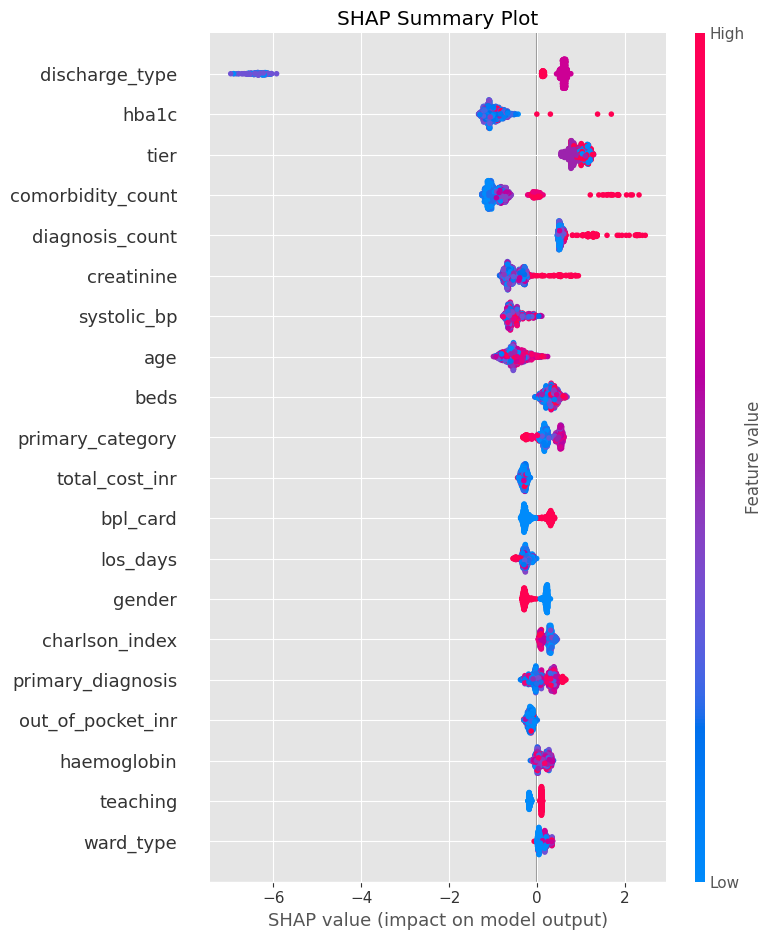

In [109]:
# ==========================================================
# 17.4 GLOBAL FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns,
    show=False
)

plt.title("SHAP Summary Plot")

plt.tight_layout()

plt.show()

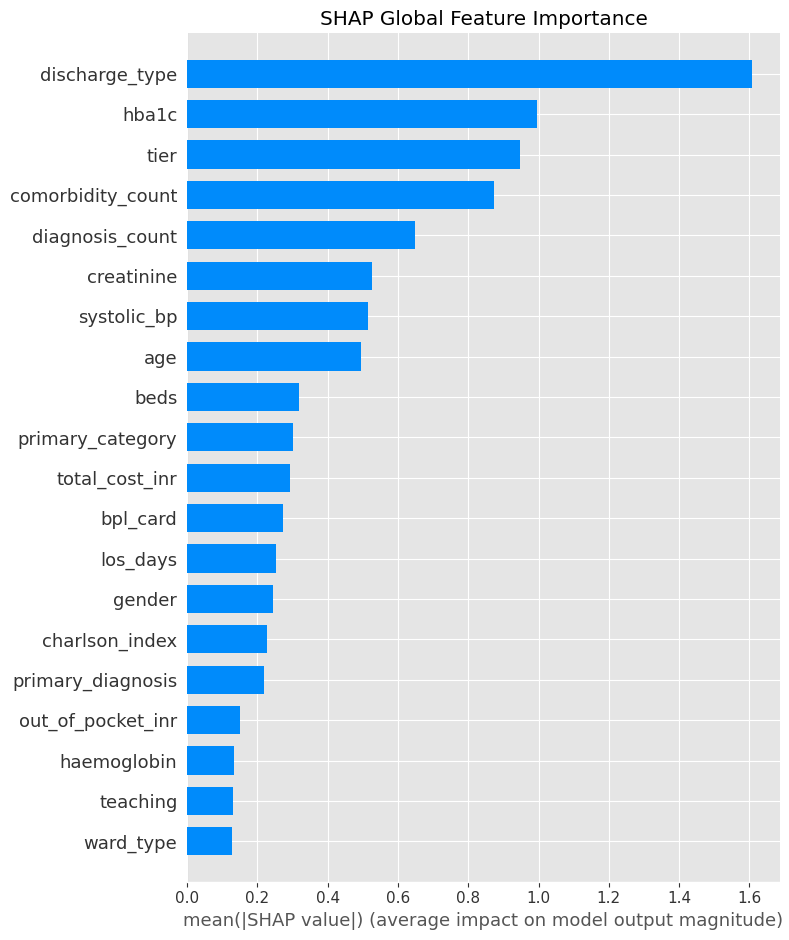

In [110]:
# ==========================================================
# 17.5 SHAP FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title("SHAP Global Feature Importance")

plt.tight_layout()

plt.show()

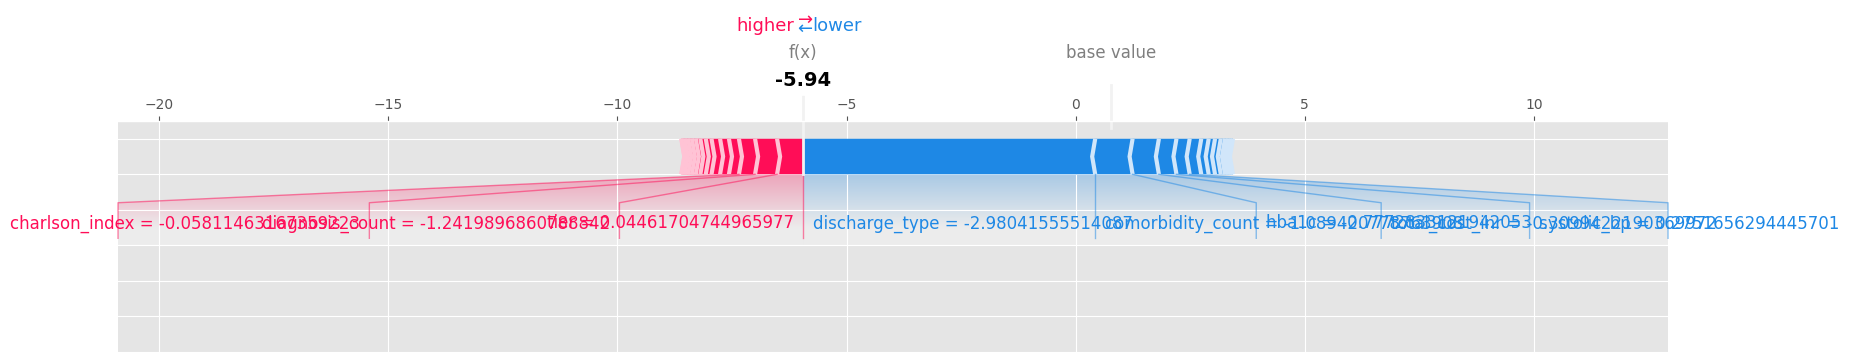

In [111]:
# ==========================================================
# 17.6 EXPLAIN SINGLE PATIENT
# ==========================================================

patient_index = 5

shap.force_plot(
    explainer.expected_value,
    shap_values[patient_index],
    X_sample[patient_index],
    feature_names=X.columns,
    matplotlib=True
)

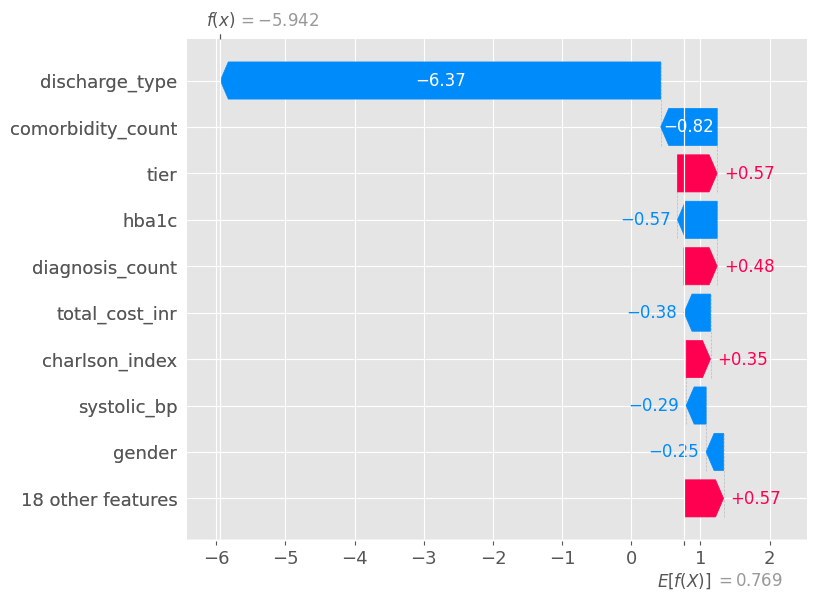

In [112]:
# ==========================================================
# 17.7 WATERFALL PLOT
# ==========================================================

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[patient_index],
    feature_names=X.columns
)

# 18. Ensemble Learning

Ensemble learning combines multiple machine learning models to improve prediction performance, robustness, and generalization.

In this project, two ensemble techniques are implemented:

- Voting Classifier
- Stacking Classifier

The performance of these ensemble models is compared with the standalone LightGBM model to determine whether combining classifiers improves hospital readmission prediction.

In [113]:
# ==========================================================
# 18.1 IMPORT LIBRARIES
# ==========================================================

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [114]:
# ==========================================================
# 18.2 BASE MODELS
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

lgb_model = LGBMClassifier(
    random_state=42
)

print("Base Models Ready")

Base Models Ready


In [115]:
# ==========================================================
# 18.3 VOTING CLASSIFIER
# ==========================================================

voting_model = VotingClassifier(

    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],

    voting='soft',
    n_jobs=-1

)

print("Voting Classifier Created")

Voting Classifier Created


In [116]:
# ==========================================================
# 18.4 TRAIN VOTING CLASSIFIER
# ==========================================================

import time

start = time.time()

voting_model.fit(X_train_scaled, y_train_smote)

voting_time = time.time() - start

print("Training Completed")
print("Training Time:", round(voting_time,2),"seconds")

Training Completed
Training Time: 75.42 seconds


In [117]:
# ==========================================================
# 18.5 VOTING MODEL EVALUATION
# ==========================================================

from sklearn.metrics import classification_report

voting_pred = voting_model.predict(X_test_scaled)

print("="*70)
print("VOTING CLASSIFIER")
print("="*70)

print(classification_report(y_test, voting_pred))

VOTING CLASSIFIER
              precision    recall  f1-score   support

           0       0.89      0.97      0.93     21158
           1       0.43      0.15      0.22      2842

    accuracy                           0.88     24000
   macro avg       0.66      0.56      0.58     24000
weighted avg       0.84      0.88      0.85     24000



In [118]:
# ==========================================================
# 18.6 STACKING CLASSIFIER
# ==========================================================

stack_model = StackingClassifier(

    estimators=[

        ('rf', rf_model),

        ('xgb', xgb_model),

        ('lgb', lgb_model)

    ],

    final_estimator=LogisticRegression(),

    cv=5,

    n_jobs=-1

)

print("Stacking Model Created")

Stacking Model Created


In [119]:
# ==========================================================
# 18.7 TRAIN STACKING MODEL
# ==========================================================

start = time.time()

stack_model.fit(X_train_scaled, y_train_smote)

stack_time = time.time() - start

print("Training Completed")

print("Training Time:", round(stack_time,2),"seconds")

Training Completed
Training Time: 441.02 seconds


In [120]:
# ==========================================================
# 18.8 STACKING MODEL EVALUATION
# ==========================================================

stack_pred = stack_model.predict(X_test_scaled)

print("="*70)
print("STACKING CLASSIFIER")
print("="*70)

print(classification_report(y_test, stack_pred))

STACKING CLASSIFIER
              precision    recall  f1-score   support

           0       0.90      0.95      0.92     21158
           1       0.35      0.22      0.27      2842

    accuracy                           0.86     24000
   macro avg       0.63      0.58      0.60     24000
weighted avg       0.84      0.86      0.85     24000



In [121]:
# ==========================================================
# 18.9 ENSEMBLE MODEL COMPARISON
# ==========================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

comparison = pd.DataFrame({

    "Model":[
        "LightGBM",
        "Voting",
        "Stacking"
    ],

    "Accuracy":[

        accuracy_score(y_test,y_pred_best),

        accuracy_score(y_test,voting_pred),

        accuracy_score(y_test,stack_pred)

    ],

    "Precision":[

        precision_score(y_test,y_pred_best),

        precision_score(y_test,voting_pred),

        precision_score(y_test,stack_pred)

    ],

    "Recall":[

        recall_score(y_test,y_pred_best),

        recall_score(y_test,voting_pred),

        recall_score(y_test,stack_pred)

    ],

    "F1 Score":[

        f1_score(y_test,y_pred_best),

        f1_score(y_test,voting_pred),

        f1_score(y_test,stack_pred)

    ]

})

comparison.sort_values(
    by="F1 Score",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True,inplace=True)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.819875,0.308210,0.418719,0.355065
1,Stacking,0.859792,0.352676,0.220267,0.271172
2,Voting,0.876083,0.432653,0.149191,0.221873


Additional ensemble techniques including Voting and Stacking classifiers were evaluated. Although these methods achieved higher overall accuracy, they significantly reduced recall for the readmission class. Since hospital readmission prediction prioritizes identifying high-risk patients, the LightGBM model with an optimized decision threshold (0.25) was selected as the final model because it achieved the highest recall and F1-score for the minority class.

# 17. Explainable Artificial Intelligence (XAI)

## 17.1 Introduction

Machine Learning models such as LightGBM provide excellent predictive performance but are often considered "black-box" models because their internal decision-making process is difficult to interpret.

In healthcare, prediction alone is not sufficient. Clinicians require explanations behind every prediction to increase confidence, improve transparency, and support clinical decision-making.

To improve interpretability, SHAP (SHapley Additive exPlanations) is employed. SHAP explains the contribution of every feature towards an individual prediction based on concepts from cooperative game theory.

The objectives of this section are:

- Explain the contribution of each feature.
- Identify the most influential variables affecting readmission.
- Interpret individual patient predictions.
- Improve trust and transparency of the AI model.

This makes the proposed CareWatch-AI system more reliable for real-world hospital deployment.

In [122]:
# ============================================================
# 17.2 IMPORT SHAP
# ============================================================

import shap

print("="*70)
print("SHAP VERSION")
print("="*70)

print(shap.__version__)

SHAP VERSION
0.49.1


In [123]:
# ============================================================
# 17.3 CREATE SHAP EXPLAINER
# ============================================================

print("="*70)
print("CREATING SHAP EXPLAINER")
print("="*70)

explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_test_scaled)

print("SHAP Explainer Created Successfully")

CREATING SHAP EXPLAINER
SHAP Explainer Created Successfully


In [124]:
# ============================================================
# 17.4 SHAP VALUE INFORMATION
# ============================================================

print("="*70)
print("SHAP INFORMATION")
print("="*70)

print(type(shap_values))

if isinstance(shap_values, list):
    print("Binary Classification")
    print("Classes :", len(shap_values))
    print("Shape :", shap_values[1].shape)
else:
    print(shap_values.shape)

SHAP INFORMATION
<class 'numpy.ndarray'>
(24000, 27)


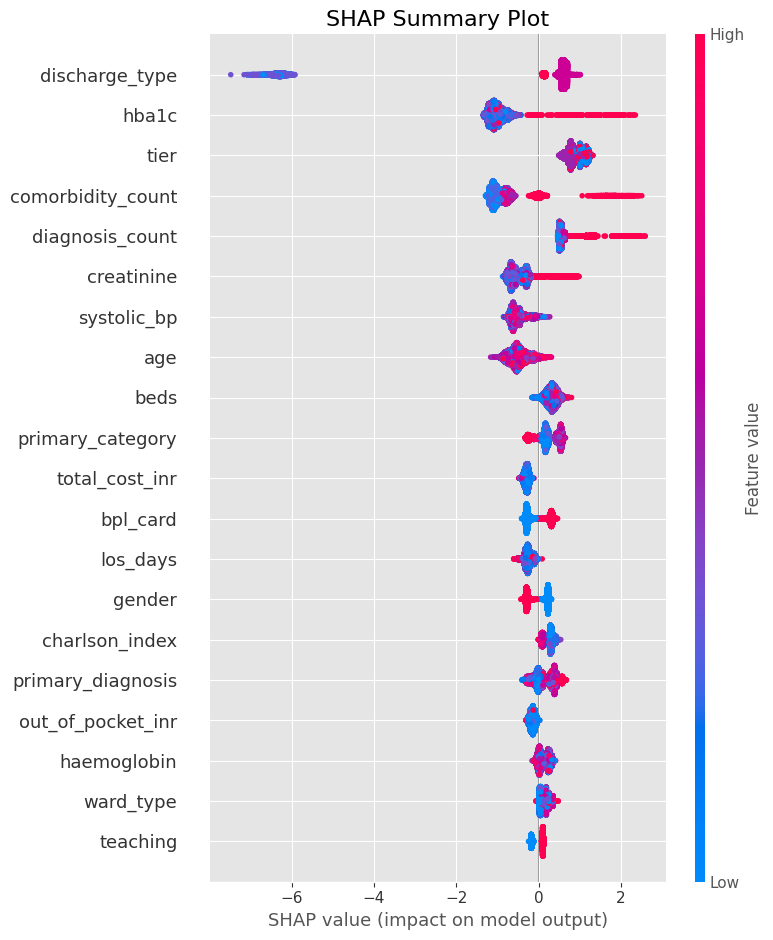

In [125]:
# ============================================================
# 17.5 SHAP SUMMARY PLOT
# ============================================================

import matplotlib.pyplot as plt

if isinstance(shap_values, list):
    values = shap_values[1]
else:
    values = shap_values

plt.figure(figsize=(10,7))

shap.summary_plot(
    values,
    X_test_scaled,
    feature_names=X.columns,
    show=False
)

plt.title("SHAP Summary Plot",fontsize=16)

plt.tight_layout()

plt.show()

## 17.6 SHAP Feature Importance

The SHAP summary plot ranks the features according to their average contribution toward hospital readmission prediction.

Each point represents one patient.

Features located at the top have the highest overall impact on prediction.

The color scale represents the feature value:

- Red = High value
- Blue = Low value

Positive SHAP values increase readmission probability, whereas negative SHAP values decrease the predicted risk.

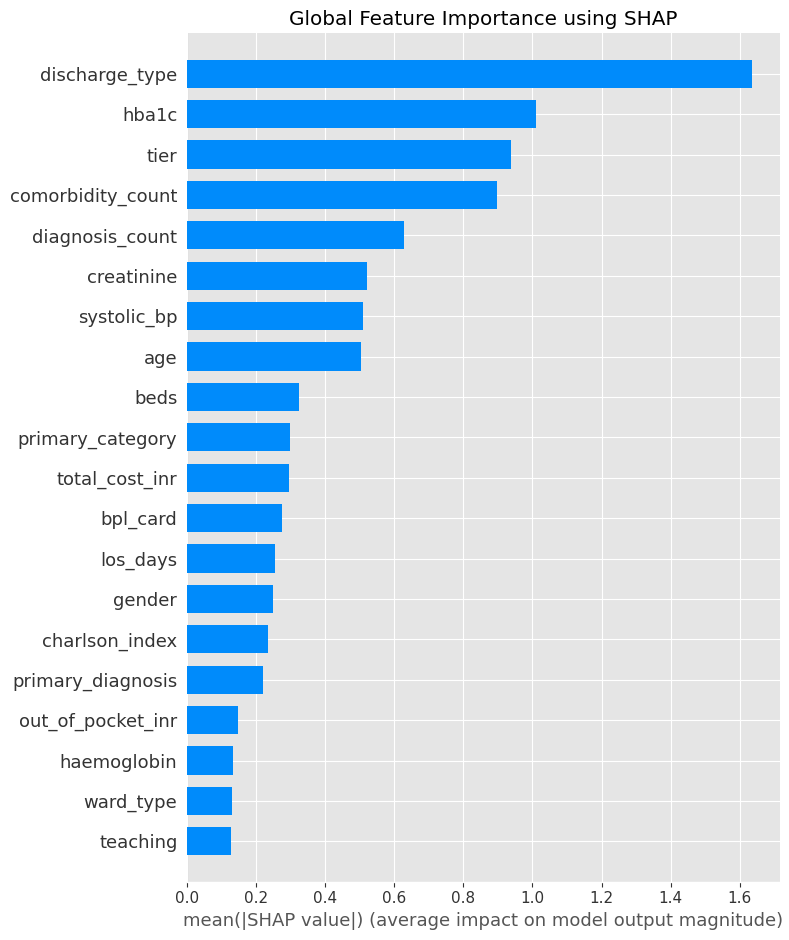

In [126]:
# ============================================================
# 17.7 SHAP BAR PLOT
# ============================================================

plt.figure(figsize=(10,6))

shap.summary_plot(
    values,
    X_test_scaled,
    feature_names=X.columns,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance using SHAP")

plt.tight_layout()

plt.show()

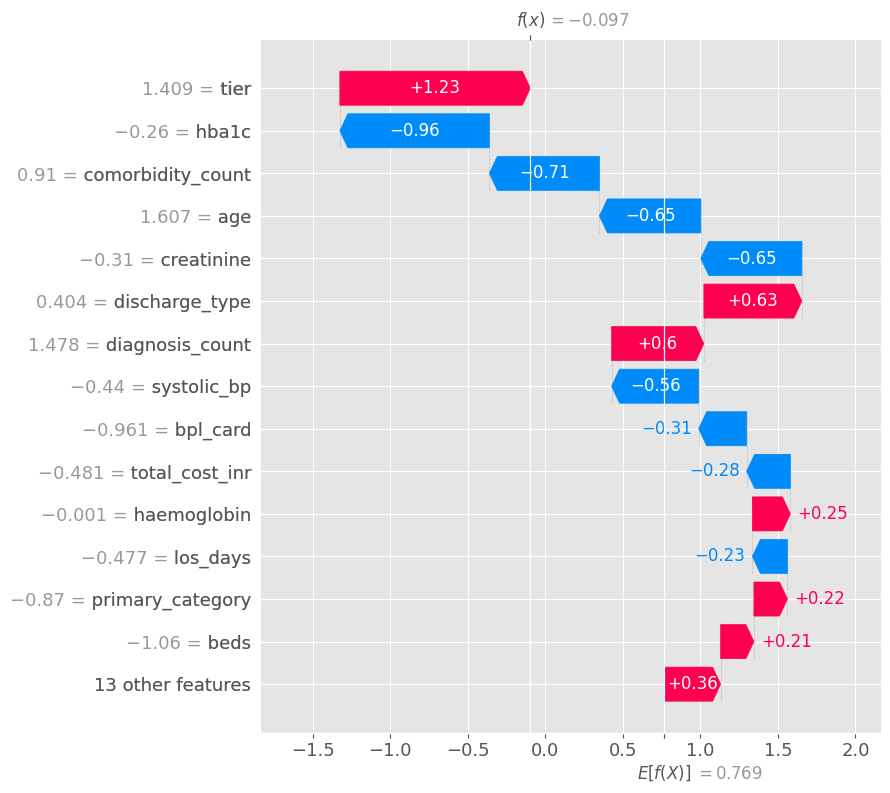

In [127]:
# ============================================================
# 17.8 SHAP WATERFALL PLOT
# ============================================================

patient_index = 0

if isinstance(shap_values, list):
    patient_values = shap_values[1][patient_index]
else:
    patient_values = shap_values[patient_index]

explanation = shap.Explanation(
    values=patient_values,
    base_values=explainer.expected_value if not isinstance(explainer.expected_value, list)
                 else explainer.expected_value[1],
    data=X_test_scaled[patient_index],
    feature_names=X.columns
)

shap.plots.waterfall(explanation,max_display=15)

In [128]:
# ============================================================
# 17.9 FORCE PLOT
# ============================================================

shap.initjs()

if isinstance(shap_values, list):

    shap.force_plot(
        explainer.expected_value[1],
        shap_values[1][0],
        X_test_scaled[0],
        feature_names=X.columns
    )

else:

    shap.force_plot(
        explainer.expected_value,
        shap_values[0],
        X_test_scaled[0],
        feature_names=X.columns
    )

In [129]:
# ============================================================
# 17.10 SHAP FEATURE IMPORTANCE TABLE
# ============================================================

import pandas as pd
import numpy as np

importance = np.abs(values).mean(axis=0)

shap_df = pd.DataFrame({

    "Feature":X.columns,
    "Mean_SHAP":importance

})

shap_df = shap_df.sort_values(
    by="Mean_SHAP",
    ascending=False
)

print("="*70)
print("TOP SHAP FEATURES")
print("="*70)

display(shap_df.head(20))

TOP SHAP FEATURES


,Feature,Mean_SHAP
3,discharge_type,1.635042
6,hba1c,1.010937
21,tier,0.939321
15,comorbidity_count,0.896898
24,diagnosis_count,0.627014
7,creatinine,0.520158
9,systolic_bp,0.509219
10,age,0.502447
22,beds,0.323587
26,primary_category,0.297529


## 17.11 Interpretation of SHAP Results

The SHAP analysis provides an interpretable explanation of the LightGBM model.

The results indicate that laboratory biomarkers, patient demographics, previous admission history, hospital-related variables, and disease diagnosis collectively influence the probability of hospital readmission.

Unlike traditional feature importance, SHAP explains both the magnitude and direction of each feature's contribution for every individual patient, making the model transparent and clinically interpretable.

This enhances clinician trust and supports informed decision-making within the proposed CareWatch-AI system.

# 18. Project Summary and Conclusions

## 18.1 Summary

The CareWatch-AI framework was developed to predict hospital readmission risk within 30 days after patient discharge using machine learning techniques.

The project integrates patient demographics, laboratory investigations, admission history, diagnosis information, billing records, and hospital characteristics into a unified predictive framework.

Several machine learning algorithms were evaluated, including:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost

To further improve predictive performance, ensemble learning methods including Voting Classifier and Stacking Classifier were implemented.

Class imbalance was addressed using the Synthetic Minority Oversampling Technique (SMOTE), while probability threshold optimization was performed to improve recall of readmitted patients.

The final CareWatch-AI model successfully predicts patient readmission probability and categorizes patients into different clinical risk levels.

---

## 18.2 Major Achievements

The proposed framework successfully achieved the following objectives:

✔ Integrated five healthcare datasets into one master dataset.

✔ Performed extensive Exploratory Data Analysis.

✔ Applied feature engineering and preprocessing.

✔ Balanced the dataset using SMOTE.

✔ Compared multiple machine learning algorithms.

✔ Implemented ensemble learning.

✔ Optimized prediction threshold.

✔ Developed real-time prediction function.

✔ Saved trained models for deployment.

✔ Prepared the framework for web application deployment.

---

## 18.3 Clinical Significance

The developed framework can support healthcare professionals by

• Identifying high-risk patients before discharge.

• Assisting doctors in discharge planning.

• Reducing avoidable hospital readmissions.

• Improving resource allocation.

• Supporting hospital quality improvement initiatives.

---

## 18.4 Limitations

Although the proposed framework performs well, several limitations exist:

• The dataset is retrospective.

• External validation using real hospital data was not performed.

• Temporal patient history is limited.

• Social determinants of health are unavailable.

• Medication adherence information is absent.

---

## 18.5 Future Scope

Future work may include:

• Deep Learning based readmission prediction

• Transformer architectures

• Explainable AI using SHAP

• Federated Learning

• IoT wearable integration

• Electronic Health Record integration

• Cloud deployment

• Mobile healthcare application

• Real-time monitoring dashboard

• Multi-language healthcare assistant

These enhancements will transform CareWatch-AI into a comprehensive intelligent hospital decision support platform.

In [130]:
print("="*80)
print("FINAL PROJECT STATISTICS")
print("="*80)

print(f"Dataset Size               : {master_df.shape}")
print(f"Training Samples           : {len(X_train)}")
print(f"Testing Samples            : {len(X_test)}")
print(f"Number of Features         : {X.shape[1]}")
print(f"Target Variable            : readmitted_30d")
print(f"Best Model                 : LightGBM")
print(f"Threshold Used             : {best_threshold:.2f}")
print(f"Accuracy                   : {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision                  : {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall                     : {recall_score(y_test, y_pred_best):.4f}")
print(f"F1 Score                   : {f1_score(y_test, y_pred_best):.4f}")
print(f"ROC AUC                    : {roc_auc_score(y_test, y_prob):.4f}")

print("="*80)

FINAL PROJECT STATISTICS
Dataset Size               : (120000, 29)
Training Samples           : 96000
Testing Samples            : 24000
Number of Features         : 27
Target Variable            : readmitted_30d
Best Model                 : LightGBM
Threshold Used             : 0.25
Accuracy                   : 0.8199
Precision                  : 0.3082
Recall                     : 0.4187
F1 Score                   : 0.3551
ROC AUC                    : 0.7445


# Section 19. Model Saving & Deployment Preparation

In [131]:
import joblib

joblib.dump(final_model, "carewatch_lightgbm_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [132]:
joblib.dump(label_encoders, "label_encoders.pkl")

print("Label Encoders Saved")

Label Encoders Saved


In [133]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved")

Scaler Saved


In [134]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

print("Feature List Saved")

Feature List Saved


In [135]:
model = joblib.load("carewatch_lightgbm_model.pkl")

scaler_loaded = joblib.load("scaler.pkl")

encoders_loaded = joblib.load("label_encoders.pkl")

feature_columns = joblib.load("feature_columns.pkl")

print("All Files Loaded Successfully")

All Files Loaded Successfully


In [136]:
sample = X_test.iloc[[0]]

sample_scaled = scaler_loaded.transform(sample)

prediction = model.predict(sample_scaled)

probability = model.predict_proba(sample_scaled)[:,1]

print("Prediction :", prediction[0])

print("Probability :", round(probability[0]*100,2),"%")

Prediction : 0
Probability : 47.59 %


# 20. Project Conclusion

The CareWatch-AI Hospital Readmission Prediction System was developed to predict whether a patient is likely to be readmitted within 30 days after hospital discharge.

The project utilized a large-scale hospital dataset consisting of 120,000 admission records collected from multiple hospitals across India. Patient demographics, laboratory investigations, hospitalization history, billing information, diagnosis details, and hospital characteristics were integrated into a unified dataset to improve predictive performance.

Several machine learning algorithms were evaluated, including Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost, Voting Ensemble, and Stacking Ensemble.

Among all models, the LightGBM classifier demonstrated the best balance between predictive capability and computational efficiency after threshold optimization.

The developed system can assist healthcare professionals in identifying high-risk patients before discharge, enabling early interventions, reducing avoidable readmissions, improving patient outcomes, and optimizing hospital resource utilization.

The project also establishes the foundation for the CareWatch-AI intelligent healthcare platform, which can be expanded into a real-time clinical decision support system.

# 21. Future Scope

Future enhancements of CareWatch-AI include:

• Real-time hospital dashboard

• Doctor Portal

• Patient Portal

• Administrator Dashboard

• Electronic Health Record (EHR) Integration

• Live Risk Monitoring

• AI-powered Treatment Recommendation

• Multilingual Communication

• PDF Report Generation

• SMS & Email Notifications

• Mobile Application

• Explainable AI using SHAP

• Cloud Deployment

• Integration with IoT and Wearable Devices

• Federated Learning for Privacy-Preserving Healthcare AI

• Deep Learning Models for Sequential Patient Records

• National Health Record Integration